# Proyecto final

## La forma del microbioma: de la geometría a la biología

En este proyecto van a trabajar con un conjunto de datos de microbioma humano acompañado de variables clínicas y dietarias. El objetivo es emplear herramientas geométricas y topológicas para responder preguntas concretas sobre estos datos.

## Preguntas centrales

**¿El microbioma se organiza como grupos separados o como un continuo?**

**¿Qué cambia de manera más clara al recorrer esa estructura: el perfil cardiometabólico o la dieta?**

---

## Cómo está diseñado este cuaderno

En este proyecto **no** se espera que exploren muchas variantes técnicas. Para que el foco esté en la interpretación, este cuaderno fija una representación razonable del microbioma y una construcción concreta de Mapper.

Su trabajo consiste en:

1. entender la forma global de los datos,
2. relacionar esa forma con variables clínicas y dietarias,
3. interpretar regiones y extremos de la estructura,
4. explorar al menos un camino alterno razonable,
5. y construir una conclusión biológica bien justificada.

---

## Entregable

Entreguen un cuaderno totalmente ejecutado que contenga:

- sus respuestas en las celdas de Markdown,
- todas las figuras y tablas generadas,
- una conclusión final clara y honesta,
- y al menos un intento de exploración alterna, aunque no haya producido una señal fuerte.

No se evalúa quién produce la gráfica más llamativa. Se evalúa qué tan bien conectan la geometría con la biología de los datos.

## Parte 0. Antes de empezar

En este proyecto vamos a trabajar con estas decisiones ya fijadas:

- **unidad de análisis:** cada muestra/persona será un punto,
- **nivel taxonómico principal:** género,
- **geometría principal:** Bray--Curtis sobre abundancias relativas,
- **control geométrico:** CLR a nivel de género,
- **Mapper principal:** lente = PCoA1 + densidad local.

La idea es que ustedes no peleen con hiperparámetros, sino que interpreten una estructura ya razonablemente construida.

In [ ]:
# Si trabajas en Colab, esta celda instala la librería que falta.
# Si ya está instalada, no pasa nada.

try:
    import kmapper as km
except ModuleNotFoundError:
    !pip -q install kmapper
    import kmapper as km

In [ ]:
from pathlib import Path
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import kmapper as km
from scipy.stats import spearmanr, pearsonr
from scipy.stats import mannwhitneyu
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import seaborn as sns
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [ ]:
# Si trabajas en Colab, esta celda instala las librerías topológicas que faltan.
# Si ya están instaladas, no pasa nada.

try:
    from ripser import ripser
    from persim import plot_diagrams
except ModuleNotFoundError:
    !pip -q install ripser persim
    from ripser import ripser
    from persim import plot_diagrams

In [ ]:
BASE = Path(".").resolve()

def find_data_folder():
    if (BASE / "microbio_selected.meta").exists():
        return BASE
    if (BASE / "datos.zip").exists():
        out = BASE / "datos_extraidos"
        out.mkdir(exist_ok=True)
        with zipfile.ZipFile(BASE / "datos.zip", "r") as z:
            z.extractall(out)
        return out
    raise FileNotFoundError("No encontré los archivos. Pon aquí el zip datos.zip o los archivos descomprimidos.")

DATA = find_data_folder()

meta = pd.read_csv(DATA / "microbio_selected.meta", sep="\t")
otus = pd.read_csv(DATA / "microbio_selected.otus", sep="\t")
taxonomy = pd.read_csv(DATA / "microbio_selected.taxonomy", sep="\t")

print("meta:", meta.shape)
print("otus:", otus.shape)
print("taxonomy:", taxonomy.shape)

meta: (446, 32)
otus: (446, 4739)
taxonomy: (4738, 3)


## Parte 1. Entender la forma de los datos

Antes de construir la representación geométrica, revisen qué tipo de tablas están usando.

### Pregunta 1
Expliquen brevemente:

- qué representa una fila en `meta`,
- qué representa una fila en `otus`,
- y por qué tiene sentido pensar que cada muestra será un punto.

### Respuesta del equipo

En el proyecto trabajamos con tres bases de datos. La tabla meta contiene la información de cada individuo, como ciudad, sexo, rango de edad y variables clínica o dietarias, por ejemplo triglicéridos, glucosa, BMI o consumo de nutrientes. Por eso cada fila de meta representa a un individuo o muestra.

Por otro lado, la tabla otus contiene la información del microbioma intestinal. En esta tabla, cada fila también representa una muestra de un individuo, y cada columna representa una OTU. Una OTu es un grupo de secuencias bacterianas similares. Por lo tanto, los valores de la tabla indican la abundancia de cada OTU en la muestra de cada persona.

También tenemos la tabla taxonomy, que relaciona cada OTU con su clasificación taxonómica, indicando a qué reino, fila, clase, orden, familia, género y especie pertenece cada agrupación. Esto nos permite identificar biológicamente las OTUs.

Tiene sentido pensar que cada muestra será un punto porque cada muestra puede representarse como un vector de abundancias de OTUs. Es decir, cada individuo tiene una composición microbioma propia. Luego podemos comparar a esos puntos usando una métrica de distancia, como Bray-Curtis, para saber qué muestras tienen microbiomas más parecidos o más diferentes.

In [ ]:
meta.head()

,ID,city,sex,age,age_range,HDL,LDL,cholesterol,triglycerides,hsCRP,...,waist,medicament,fiber,per_protein,per_animal_protein,per_total_fat,per_saturated_fat,per_monoinsaturated_fat,per_polyunsaturated_fat,per_carbohydrates
0,MI_001_H,Medellin,Male,36,18_40,38,93,170,195,"1,71",...,"97,6",No,19,"16,15","60,53","28,4","11,01","9,88","4,82","55,47"
1,MI_002_H,Medellin,Female,40,18_40,52,130,202,100,"0,32",...,"89,3",No,13,"13,77","66,88","29,74","11,61","10,35","6,55","56,1"
2,MI_003_H,Medellin,Male,53,41_62,51,119,185,76,"1,84",...,"92,8",No,13,"14,57","64,75","24,2","9,48","8,1","4,84","61,37"
3,MI_004_H,Medellin,Male,58,41_62,59,120,199,99,"0,86",...,"84,7",Yes,16,"19,17","65,78","28,72","11,6","10,63","5,03","51,28"
4,MI_005_H,Medellin,Female,44,41_62,73,63,159,114,"0,43",...,"73,3",Yes,21,"13,86","59,4","28,4","9,91","9,66","6,92","57,5"


In [ ]:
otus.iloc[:5, :8]

,samples,Otu00001,Otu00002,Otu00003,Otu00004,Otu00005,Otu00006,Otu00007
0,MI_001_H,354,817,50,31,448,547,727
1,MI_002_H,168,9,131,3005,68,10187,570
2,MI_003_H,19,174,6211,79,1063,0,6077
3,MI_004_H,264,1816,159,16,110,4,12
4,MI_005_H,0,2,0,12,598,39,0


In [ ]:
taxonomy.head()

,OTU,Size,Taxonomy
0,Otu00001,136589,k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o_...
1,Otu00002,1139018,k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o_...
2,Otu00003,452087,k__Bacteria;p__Firmicutes;c__Clostridia;o__Clo...
3,Otu00004,1182065,k__Bacteria;p__Proteobacteria;c__Gammaproteoba...
4,Otu00005,265091,k__Bacteria;p__Firmicutes;c__Clostridia;o__Clo...


### Limpieza mínima y agregación a género

Vamos a transformar los datos de OTUs a nivel de género. Esto reduce ruido y hace más interpretable la composición microbiana.

In [ ]:
meta_clean = meta.copy()

for col in meta_clean.columns:
    if meta_clean[col].dtype == object:
        s = meta_clean[col].astype(str).str.replace(",", ".", regex=False)
        conv = pd.to_numeric(s, errors="coerce")
        nonnull = meta_clean[col].notna().sum()
        if (
            nonnull > 0
            and conv.notna().sum() / nonnull > 0.8
            and col not in [
                "ID", "city", "sex", "age_range",
                "stool_consistency", "hiden_blood",
                "bmi_class", "medicament"
            ]
        ):
            meta_clean[col] = conv

meta_clean = meta_clean.set_index("ID")
otus_counts = otus.set_index("samples").loc[meta_clean.index]

def extract_rank(tax_str, prefix):
    if pd.isna(tax_str):
        return "Unassigned"
    for part in str(tax_str).split(";"):
        if part.startswith(prefix):
            value = part[len(prefix):].strip()
            return value if value else "Unassigned"
    return "Unassigned"

taxonomy["genus"] = taxonomy["Taxonomy"].apply(lambda s: extract_rank(s, "g__"))
otu_to_genus = taxonomy.set_index("OTU")["genus"]

common = [c for c in otus_counts.columns if c in otu_to_genus.index]
genus_counts = otus_counts[common].T.groupby(otu_to_genus.loc[common]).sum().T

print("Matriz a nivel de género:", genus_counts.shape)
print("Valores faltantes en metadata:", int(meta_clean.isna().sum().sum()))

Matriz a nivel de género: (446, 430)
Valores faltantes en metadata: 3


In [ ]:
X_rel = genus_counts.div(genus_counts.sum(axis=1), axis=0)

sparsity = 1 - (X_rel.to_numpy() > 0).mean()
print(f"Fracción de ceros en la matriz a nivel de género: {sparsity:.3f}")

present_in = (X_rel > 0).mean(axis=0)
present_in.describe()

Fracción de ceros en la matriz a nivel de género: 0.814


,0
count,430.000000
mean,0.186036
std,0.307470
min,0.002242
25%,0.002242
50%,0.013453
75%,0.211883
max,1.000000


### Pregunta 2
Comenten dos cosas:

1. ¿Qué se gana al pasar de OTU a género?
2. ¿Qué se pierde?

### Respuesta del equipo
Al agregar nuestras OTUs a nivel de género, las abundancias de las OTUs que pretenecen al mismo grupo bacteriano se combinan en una sola categoría. Esto reduce considerablemente la cantidad de variables: en nuestro caso pasamos de miles de OTUs a 430 géneros bacterianos. Aun así, observamos que el 81.4% de la matriz sigue siendo cero, lo que indica que muchos géneros todavía son raros y aparecen en pocas muestras.

Al hacer esta agregación ganamos una interpretación biológica más sencilla y un análisis más manejable, ya que trabajar con géneros bacterianos como Prevotella, Bacteroides o Faecalibacterium es más interpretable que trabajar con miles de OTUs individuales. Además, reducir dimensionalidad ayuda a disminuir ruido en los datls.

Sin embargo, también se pierde información específica de ciertas OTUs, ya que varias OTUs diferentes quedan combinadas dentro del mismo género. Esto puede ocultar patrones particulares biológicos que podrían ser relevantes.

## Parte 2. Construir la geometría principal

Usaremos Bray--Curtis sobre abundancias relativas a nivel de género y luego una representación PCoA.

In [ ]:
D_bray = pairwise_distances(X_rel.values, metric="braycurtis")

def pcoa(D, n_components=10):
    n = D.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * H @ (D ** 2) @ H
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    pos = eigvals > 1e-10
    eigvals = eigvals[pos]
    eigvecs = eigvecs[:, pos]
    k = min(n_components, eigvecs.shape[1])
    return eigvecs[:, :k] * np.sqrt(eigvals[:k]), eigvals[:k]

coords_bray, eig_bray = pcoa(D_bray, 10)
print("Varianza relativa explicada por PCoA 1--5:", np.round(eig_bray / eig_bray.sum(), 3)[:5])

Varianza relativa explicada por PCoA 1--5: [0.217 0.176 0.164 0.108 0.078]


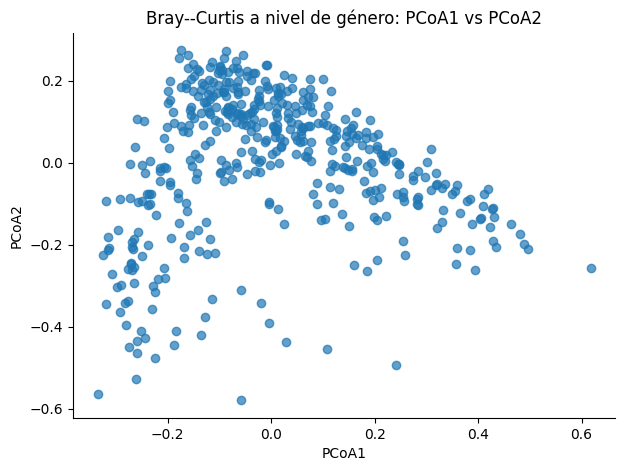

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(coords_bray[:, 0], coords_bray[:, 1], alpha=0.7)
ax.set_title("Bray--Curtis a nivel de género: PCoA1 vs PCoA2")
ax.set_xlabel("PCoA1")
ax.set_ylabel("PCoA2")
plt.show()

### Pregunta 3
A partir de esta proyección, den una primera impresión:

- ¿ven grupos claramente separados?
- ¿ven una nube continua?
- ¿ven indicios de regiones o ramas?

No den una respuesta definitiva todavía. Solo una impresión inicial.

### Respuesta del equipo
En la gráfica se observa la representación PCoA usando Bray-Curtis a nivel de género. A simple visto no se ven grupos claramente separados, la mayoría de las muestras forman una nube continua y relativamente densa. Esto sugiere que los microbiomas no se dividen en clusters discretos, sino que parecen veriar de manera gradual entre individuos. También se observan algunos puntos extremos alejados de la nube principa, que podrían corresponder a indivuduos con composiciones microbianas atípicas. Además, podría existir una ligera rama o extensión hacia la parte inferior izquierda, aunque no es una separación clara. En general, la primera impresión es que los datos forman una estructura continua con algunas regiones densas y puntos extremos.

## Parte 2A. Vecindad, abiertos y cerrados

La métrica fija qué muestras quedan cerca. Con esa noción de cercanía se definen vecindades, bolas abiertas y bolas cerradas.

### Pregunta topológica 1

Respondan brevemente:

- qué sería aquí una **bola abierta** de radio \(r\) alrededor de una muestra,
- qué sería aquí una **bola cerrada** de radio \(r\),
- por qué cambiar de Bray--Curtis a CLR cambia la noción de cercanía y, por tanto, la topología del conjunto de datos.

### Respuesta del equipo

Una bola abierta de radio r alrededor de una muestra es el conjunto de muestras cuya distancia a esa muestra es menor que r. En cambio , una bola cerrada incluye también a las muestras que están exactamente a distancia r. En este proyecto, esa distancia puede venir de Bray-Curtis, que mide qué tan diferentes son dos microbiomas según sus abundancias relativas.

Esta noción de cercanía es importante porque define qué muestras se consideran vecinas. Por ejemplo, en Vietoris-Rips, si dos muestras están a distancia menor o igual a cierto radio, se conectan. Al aumentar el radio, aparecen conexiones, componente y posibles cicles.

Cambiair de Bray-Curtis a CLR cambia la geometría porque ya no estamos comparando las muestras de la misma manera. Bray-Curtis compara directamente las abundancias relativas y nos dice qué tandiferentes son dos microbiomas. En cambio CLR se usa como una representación alternativa de los datos composicionales del microbioma. Su objetivo es reducir el efecto de que las abundancias relativas siempre suman 1 y comparar si la estructura geométrica observada se mantiene bajo otra representación de los datos.

Entonces al usar CLR algunas muestras que antes estaban cerca pueden quedar más lejos o al revés. Eso cambia las vecindades, las conexiones entre puntos y la forma general de los datos.

En resumen, al cambiar la forma de medir la cercanía entre las muestras, también cambia la distribución de los puntos en el espacio. Como la topología depende de qué puntos se consideran cercanos, este cambio puede modificar las conexiones, los ciclos y la estructura general que observamos en el análisis.


## Parte 2B. Homología persistente de la forma global

Usen una filtración de Vietoris--Rips en dimensión 0 y 1 para estudiar la forma global de los datos.

En este contexto:

- \( \beta_0 \) cuenta componentes conexas,
- \( \beta_1 \) cuenta ciclos.

Calcularemos homología persistente para dos geometrías:

- Bray--Curtis a nivel de género,
- CLR a nivel de género.

In [ ]:
# Construcción del control CLR para la comparación topológica

X_pc_top = genus_counts + 0.5
X_comp_top = X_pc_top.div(X_pc_top.sum(axis=1), axis=0)
logX_top = np.log(X_comp_top.values)
X_clr_top = logX_top - logX_top.mean(axis=1, keepdims=True)
X_clr_top = StandardScaler().fit_transform(X_clr_top)

D_clr_top = pairwise_distances(X_clr_top, metric="euclidean")

def normalize_distance_matrix(D):
    D = np.asarray(D, dtype=float).copy()
    nz = D[D > 0]
    scale = np.median(nz)
    return D / scale

D_bray_top = normalize_distance_matrix(D_bray)
D_clr_top = normalize_distance_matrix(D_clr_top)

ph_bray = ripser(D_bray_top, distance_matrix=True, maxdim=1)["dgms"]
ph_clr = ripser(D_clr_top, distance_matrix=True, maxdim=1)["dgms"]

print("Bray y CLR listos para homología persistente.")

Bray y CLR listos para homología persistente.


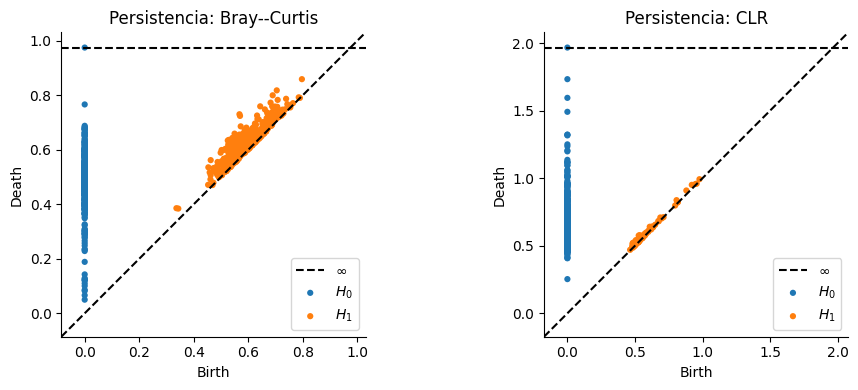

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_diagrams(ph_bray, ax=axes[0], show=False)
axes[0].set_title("Persistencia: Bray--Curtis")

plot_diagrams(ph_clr, ax=axes[1], show=False)
axes[1].set_title("Persistencia: CLR")

plt.tight_layout()
plt.show()

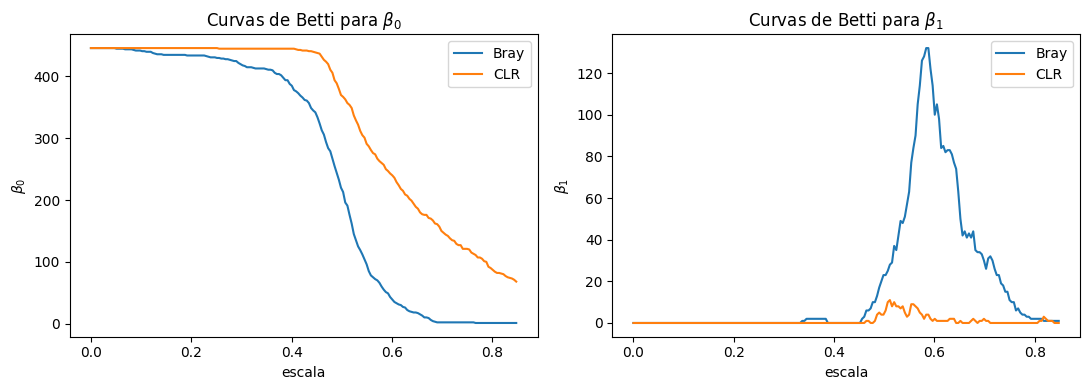

Resumen topológico


,geometry,max_persistence_beta0,median_persistence_beta0,max_persistence_beta1,median_persistence_beta1,n_beta1_bars,n_beta1_persistence_gt_0.20
0,Bray--Curtis,0.766177,0.497362,0.162526,0.026011,477,0
1,CLR,1.732616,0.613592,0.047766,0.007813,84,0


Top persistencias en H1 para Bray--Curtis


,birth,death,persistence
0,0.567729,0.730255,0.162526
1,0.569741,0.724101,0.154361
2,0.643830,0.759249,0.115420
3,0.572284,0.685810,0.113526
4,0.704547,0.817834,0.113287
5,0.689612,0.799770,0.110159
6,0.549719,0.659145,0.109426
7,0.524818,0.633801,0.108983
8,0.528518,0.636100,0.107583
9,0.541194,0.643067,0.101872


Top persistencias en H1 para CLR


,birth,death,persistence
0,0.527552,0.575318,0.047766
1,0.535047,0.578545,0.043498
2,0.484153,0.521026,0.036874
3,0.506448,0.541428,0.034981
4,0.481903,0.513213,0.031311
5,0.609346,0.640554,0.031208
6,0.488915,0.519490,0.030575
7,0.920598,0.950594,0.029996
8,0.498724,0.528669,0.029946
9,0.807777,0.837380,0.029602


In [ ]:
def betti_curve(diagram, grid):
    d = np.asarray(diagram, dtype=float)
    counts = []
    for t in grid:
        alive = (d[:, 0] <= t) & ((t < d[:, 1]) | np.isinf(d[:, 1]))
        counts.append(int(alive.sum()))
    return np.array(counts)

def persistence_table(diagram, top_n=10):
    d = np.asarray(diagram, dtype=float)
    finite = d[np.isfinite(d[:, 1])]
    if len(finite) == 0:
        return pd.DataFrame(columns=["birth", "death", "persistence"])
    pers = finite[:, 1] - finite[:, 0]
    order = np.argsort(-pers)
    out = pd.DataFrame(finite[order], columns=["birth", "death"])
    out["persistence"] = pers[order]
    return out.head(top_n)

def persistence_summary(diagrams, geometry):
    h0 = np.asarray(diagrams[0], dtype=float)
    h1 = np.asarray(diagrams[1], dtype=float)

    h0f = h0[np.isfinite(h0[:, 1])]
    h1f = h1[np.isfinite(h1[:, 1])]

    p0 = h0f[:, 1] - h0f[:, 0] if len(h0f) else np.array([])
    p1 = h1f[:, 1] - h1f[:, 0] if len(h1f) else np.array([])

    return {
        "geometry": geometry,
        "max_persistence_beta0": p0.max() if len(p0) else np.nan,
        "median_persistence_beta0": np.median(p0) if len(p0) else np.nan,
        "max_persistence_beta1": p1.max() if len(p1) else np.nan,
        "median_persistence_beta1": np.median(p1) if len(p1) else np.nan,
        "n_beta1_bars": len(p1),
        "n_beta1_persistence_gt_0.20": int((p1 > 0.20).sum()) if len(p1) else 0,
    }

finite_h0_deaths = []
finite_h1_deaths = []
for dgms in [ph_bray, ph_clr]:
    for dim in [0, 1]:
        d = np.asarray(dgms[dim], dtype=float)
        finite = d[np.isfinite(d[:, 1])]
        if len(finite):
            finite_h0_deaths.extend(finite[:, 1].tolist()) if dim == 0 else finite_h1_deaths.extend(finite[:, 1].tolist())

max_scale = np.percentile(finite_h0_deaths + finite_h1_deaths, 95)
grid = np.linspace(0, max_scale, 200)

b0_bray = betti_curve(ph_bray[0], grid)
b1_bray = betti_curve(ph_bray[1], grid)
b0_clr = betti_curve(ph_clr[0], grid)
b1_clr = betti_curve(ph_clr[1], grid)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(grid, b0_bray, label="Bray")
axes[0].plot(grid, b0_clr, label="CLR")
axes[0].set_title(r"Curvas de Betti para $\beta_0$")
axes[0].set_xlabel("escala")
axes[0].set_ylabel(r"$\beta_0$")
axes[0].legend()

axes[1].plot(grid, b1_bray, label="Bray")
axes[1].plot(grid, b1_clr, label="CLR")
axes[1].set_title(r"Curvas de Betti para $\beta_1$")
axes[1].set_xlabel("escala")
axes[1].set_ylabel(r"$\beta_1$")
axes[1].legend()

plt.tight_layout()
plt.show()

summary_top = pd.DataFrame([
    persistence_summary(ph_bray, "Bray--Curtis"),
    persistence_summary(ph_clr, "CLR"),
])
print("Resumen topológico")
display(summary_top)

print("Top persistencias en H1 para Bray--Curtis")
display(persistence_table(ph_bray[1], 10))

print("Top persistencias en H1 para CLR")
display(persistence_table(ph_clr[1], 10))

### Pregunta topológica 2

A partir de los diagramas, las curvas de Betti y la tabla resumen, respondan:

- qué sugiere \( \beta_0 \) sobre la conectividad global de los datos,
- qué sugiere \( \beta_1 \) sobre la presencia de ciclos fuertes o débiles,
- qué geometría deja una lectura topológica más clara,
- y por qué esta parte topológica justifica el uso posterior de Mapper.

### Respuesta del equipo
En los diagramas y curvas de Betti se observa que, al inicio de la filtración, cada muestra empieza como su propio componente conexo, por eso $\beta_0$ comienza alto. Conforme aumenta la escala, las muestras se van conectando y el número de componentes disminuye. En Bray-Curtis la conectividad aparece más rápido, mientras que en CLR los componentes tardan más en unirse, lo que sugiere que esta transformación separa más las muestras bajo esa geometría.

Para $\beta_1$, Bray-Curtis muestra una señal más fuerte de ciclos que CLR. Esto se ve porque tiene más barras en $H_1$ y mayor persistencia máxima: en Bray-Curtis la persistencia máxima de $\beta_1$ es aproximadamente 0.16, mientras que en CLR es aproximadamente 0.048. Sin embargo, ninguna geometría presenta ciclos muy persistentes mayores a 0.20, por lo que no podemos afirmar que haya huecos topológicos muy fuertes. Más bien, Bray-Curtis sugiere ciclos moderados o estructuras locales más complejas.

En general, Bray-Curtis deja una lectura topológica más informativa para este proyecto, porque muestra mejor la formación de ciclos y conexiones entre muestras. CLR sirve como comparación, pero parece producir una estructura con menos ciclos y componentes que tardan más en conectarse. Esta parte justifica usar Mapper después, porque la homología persistente nos dice que hay conectividad y posibles estructuras locales, pero no explica por sí sola qué variables clínicas o dietarias están asociadas a esas regiones. Mapper puede ayudarnos a visualizar mejor esas conexiones, regiones y posibles transiciones en la forma global de los datos.

## Parte 3. Controles categóricos rápidos

Antes de usar Mapper, revisamos si categorías gruesas como `city`, `sex` o `bmi_class` organizan realmente la representación Bray.

In [ ]:
X_bray5 = StandardScaler().fit_transform(coords_bray[:, :5])

cat_vars = ["city", "sex", "age_range", "bmi_class", "stool_consistency", "medicament", "hiden_blood"]
cat_rows = []
for var in cat_vars:
    y = meta_clean[var].fillna(meta_clean[var].mode().iloc[0])
    sil = silhouette_score(X_bray5, y)
    cat_rows.append({"variable": var, "silhouette": sil, "niveles": y.nunique()})

cat_df = pd.DataFrame(cat_rows).sort_values("silhouette", ascending=False)
cat_df

,variable,silhouette,niveles
6,hiden_blood,0.072733,2
1,sex,0.011983,2
4,stool_consistency,0.008369,4
5,medicament,0.007968,2
2,age_range,0.002403,2
3,bmi_class,-0.013512,3
0,city,-0.039281,5


### Pregunta 4
Interpreten esta tabla.

- ¿Qué variables categóricas parecen organizar mejor la nube?
- ¿Hay alguna con separación realmente fuerte?
- ¿Qué les sugiere esto sobre la pregunta “clusters o continuo”?

### Respuesta del equipo
En la tabla observamos que las variables categóricas con mayor silhouette son hidden_blood, sex y stool_consistency. Sin embargo, sus valores siguen siendo muy bajos, por lo que no indican una separación fuerte entre grupos. Esto significa que, aunque esas variables parecen organizar ligeramente mejor la nube, no forman clusters claros.

En cambio, bmi_class y city tienen valores negativos, lo que sugiere que esas categorías no separan bien las muestras en la geometría Bray-Curtis. Es decir, las muestras de una misma categoría no necesariamente están más cerca entre sí que de muestras de otras categorias.

En general, la tabla sugiere que no hay una variable categórica que divida claramente los datos en grupos separados. Esto apoya la idea de que la estructura del microbioma parece más un continuo que clusters discretos.

## Parte 4. Construir dos perfiles continuos

Vamos a trabajar con dos tipos de variables continuas:

- un **perfil cardiometabólico**,
- y un **perfil dietario**.

El objetivo no es solo ver si cambian, sino si cambian de forma coherente con la estructura geométrica encontrada.

In [ ]:
# Perfil cardiometabólico
met_pos = ["waist", "glucose", "triglycerides", "HOMA_IR", "bmi", "diastolic_bp"]
met_neg = ["HDL", "adiponectin"]

M = meta_clean[met_pos + met_neg].copy().fillna(meta_clean[met_pos + met_neg].median())
M_std = (M - M.mean()) / M.std(ddof=0)
meta_clean["met_score"] = M_std[met_pos].mean(axis=1) - M_std[met_neg].mean(axis=1)

# Perfil dietario simple
diet_cols = ["fiber", "per_carbohydrates", "per_animal_protein", "per_total_fat", "per_saturated_fat"]
D = meta_clean[diet_cols].copy().fillna(meta_clean[diet_cols].median())
D_std = (D - D.mean()) / D.std(ddof=0)
meta_clean["diet_score_simple"] = (
    D_std["fiber"]
    + D_std["per_carbohydrates"]
    - D_std["per_animal_protein"]
    - D_std["per_total_fat"]
    - D_std["per_saturated_fat"]
)

# Perfil dietario por PCA
diet_vars = [
    "fiber", "per_protein", "per_animal_protein", "per_total_fat",
    "per_saturated_fat", "per_monoinsaturated_fat",
    "per_polyunsaturated_fat", "per_carbohydrates"
]
Diet = meta_clean[diet_vars].copy().fillna(meta_clean[diet_vars].median())
diet_pcs = PCA(n_components=3).fit_transform(StandardScaler().fit_transform(Diet))
meta_clean["diet_score_pca"] = -diet_pcs[:, 0]

meta_clean[["met_score", "diet_score_simple", "diet_score_pca"]].corr()

,met_score,diet_score_simple,diet_score_pca
met_score,1.000000,0.013695,0.001371
diet_score_simple,0.013695,1.000000,0.939879
diet_score_pca,0.001371,0.939879,1.000000


### Pregunta 5
Miren la correlación entre estos tres scores.

- ¿El perfil cardiometabólico y el dietario son casi lo mismo?
- ¿O parecen capturar cosas distintas?

### Respuesta del equipo
Observamos que el perfil cardiometabólico y los perfiles dietarios tienen correlaciones muy bajas. La correlación entre met_score y diet_score_simple es aproximadamente es aproximadamente 0.014, y entre met_score y diet_score_pcs es aproximadamente 0.001. Esto sugiere que el perfil cardiometabólico y el perfil dietario capturan información distinta de los individuos.

Por otro lado, diet_score_simple y diet_score_pca tienen una correlación alta, aproximadamente 0.94, lo cual tiene sentido porque ambos se construyen a partir de variable dietarias similares. En general, esto indica que los perfiles dietarios son coherentes entre sí, pero no están fuertemente relacionados con el perfil cardiometabólico.

Por lo tanto, tiene sentido usar estos perfiles en Mapper, ya que pueden ayuda a revisar si la estructura geométrica del microbioma se relaciona más con variables cardiometabólicas o con variables dietarias.

## Parte 5. Mapper principal

Ahora construimos un Mapper fijo:

- geometría: Bray--Curtis a nivel de género,
- lente: PCoA1 + densidad local,
- clustering local: DBSCAN con parámetros fijos.

El objetivo no es optimizar Mapper, sino interpretar su estructura.

In [ ]:
def knn_density(X, k=15):
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    dists, _ = nbrs.kneighbors(X)
    return dists[:, 1:].mean(axis=1)

density = knn_density(X_bray5, 15)
lens = np.c_[coords_bray[:, 0], density]
lens = (lens - lens.min(axis=0)) / (lens.max(axis=0) - lens.min(axis=0))

mapper = km.KeplerMapper(verbose=0)
graph = mapper.map(
    lens=lens,
    X=X_bray5,
    cover=km.Cover(n_cubes=10, perc_overlap=0.35),
    clusterer=DBSCAN(eps=1.0, min_samples=4),
)

def graph_to_nx(graph):
    G = nx.Graph()
    for node, members in graph["nodes"].items():
        G.add_node(node, members=members, size=len(members))
    for node, neighbors in graph["links"].items():
        for nb in neighbors:
            G.add_edge(node, nb)
    return G

G = graph_to_nx(graph)

covered = set()
for members in graph["nodes"].values():
    covered.update(members)

summary = {
    "nodes": G.number_of_nodes(),
    "edges": G.number_of_edges(),
    "components": nx.number_connected_components(G),
    "covered_samples_fraction": len(covered) / len(meta_clean),
    "giant_component_fraction_of_nodes": max(len(c) for c in nx.connected_components(G)) / G.number_of_nodes(),
}
summary

{'nodes': 40,
 'edges': 89,
 'components': 2,
 'covered_samples_fraction': 0.7062780269058296,
 'giant_component_fraction_of_nodes': 0.975}

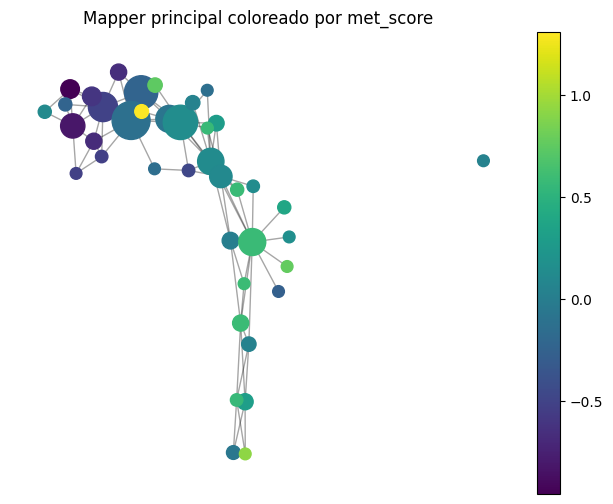

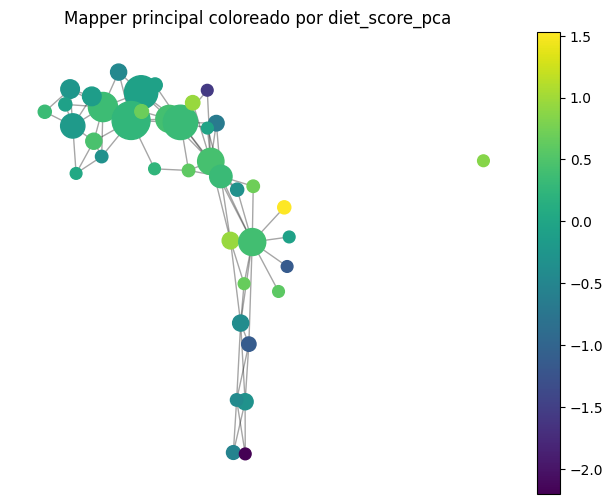

In [ ]:
def node_series_means(graph, sample_series, index):
    vals = {}
    for node, members in graph["nodes"].items():
        ids = index[members]
        vals[node] = sample_series.loc[ids].mean()
    return pd.Series(vals)

def draw_mapper_graph(graph, G, sample_series, title):
    s = sample_series.copy()
    if s.isna().any():
        s = s.fillna(s.median())
    node_vals = node_series_means(graph, s, meta_clean.index)

    pos = nx.spring_layout(G, seed=7)
    node_sizes = np.array([G.nodes[n]["size"] for n in G.nodes()])
    node_colors = np.array([node_vals.loc[n] for n in G.nodes()])

    fig, ax = plt.subplots(figsize=(8, 6))
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.35)
    nodes = nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=35 + 9 * node_sizes,
        node_color=node_colors
    )
    plt.colorbar(nodes, ax=ax)
    ax.set_title(title)
    ax.axis("off")
    plt.show()

draw_mapper_graph(graph, G, meta_clean["met_score"], "Mapper principal coloreado por met_score")
draw_mapper_graph(graph, G, meta_clean["diet_score_pca"], "Mapper principal coloreado por diet_score_pca")

### Pregunta 6
Miren el resumen del grafo y las dos coloraciones.

- ¿El grafo parece más bien fragmentado o tiene una estructura principal reconocible?
- ¿Qué variable parece cambiar de manera más ordenada sobre el grafo?
- ¿Cuál de las dos coloraciones cuenta una historia más clara?

### Respuesta del equipo
El grafo no parece fragmentado, sino que tiene una estructura principal reconocible. Se observa una región más densa en la parte superior y una rama principal que conecta acia la parte inferior, además algunas pequeñas ramificaciones laterales.

Entre las dos variables, met_score parace cambiar de manera más ordenada sobre el grafo. En varias regiones conectadas se observan colores similares, lo que sugiere cierta coherencia cardiometabólica a lo largo de la estructura.

Aunque diet_score_pca también muestra cambios de color visible, estos parecen más mezclado y menos consistentes entre regiones cercanas. Por eso, la coloración de met_score parece contar una hisotira más clara sobre la organización del microbioma en el Mapper.

## Parte 6. Medir qué tan bien una variable sigue la estructura

Para comparar variables continuas, usaremos una idea operativa:

- promediamos cada variable por nodo,
- medimos una autocorrelación espacial simple sobre el grafo,
- y la combinamos con el rango de valores entre nodos.

No es una medida sagrada. Es una forma práctica de comparar qué variable parece variar de manera suave y no trivial a lo largo de la estructura.

In [ ]:
def graph_morans_I(G, values):
    nodes = list(G.nodes())
    node_pos = {node: i for i, node in enumerate(nodes)}
    x = values.loc[nodes].values.astype(float)
    n = len(x)
    if n < 3:
        return np.nan
    xbar = x.mean()
    den = ((x - xbar) ** 2).sum()
    if den <= 0:
        return np.nan
    num = 0.0
    W = 0.0
    for u, v in G.edges():
        iu = node_pos[u]
        iv = node_pos[v]
        num += (x[iu] - xbar) * (x[iv] - xbar)
        W += 1.0
    if W == 0:
        return np.nan
    return (n / W) * (num / den)

def graph_edge_stats(G, values):
    nodes = list(G.nodes())
    vals = values.loc[nodes]
    pairs = [(vals[u], vals[v]) for u, v in G.edges()]
    if len(pairs) < 2:
        return {"edge_corr": np.nan, "edge_mad": np.nan}
    a = np.array([p[0] for p in pairs], float)
    b = np.array([p[1] for p in pairs], float)
    return {
        "edge_corr": np.corrcoef(a, b)[0, 1],
        "edge_mad": np.mean(np.abs(a - b)),
    }

def mapper_alignment(sample_series):
    s = sample_series.copy()
    if s.isna().any():
        s = s.fillna(s.median())
    s = (s - s.mean()) / s.std(ddof=0)
    node_vals = node_series_means(graph, s, meta_clean.index)
    I = graph_morans_I(G, node_vals)
    rng = node_vals.max() - node_vals.min()
    estats = graph_edge_stats(G, node_vals)
    return {
        "morans_I": I,
        "node_range": rng,
        "edge_corr": estats["edge_corr"],
        "edge_mad": estats["edge_mad"],
        "alignment_score": I * rng,
    }

In [ ]:
continuous_vars = [
    "met_score", "diet_score_simple", "diet_score_pca",
    "fiber", "per_animal_protein", "per_total_fat", "per_saturated_fat",
    "per_carbohydrates", "age", "bmi", "waist", "HDL",
    "adiponectin", "HOMA_IR", "glucose", "triglycerides", "hsCRP"
]

rows = []
for var in continuous_vars:
    rows.append({"variable": var, **mapper_alignment(meta_clean[var])})

align_df = pd.DataFrame(rows).sort_values("alignment_score", ascending=False)
align_df

,variable,morans_I,node_range,edge_corr,edge_mad,alignment_score
0,met_score,0.505523,1.822053,0.570837,0.301129,0.921090
12,adiponectin,0.456371,1.458955,0.567678,0.236924,0.665825
14,glucose,0.309279,1.909934,0.403224,0.232297,0.590703
11,HDL,0.369121,1.484330,0.518064,0.241783,0.547897
10,waist,0.297611,1.453268,0.360218,0.327313,0.432509
8,age,0.191757,2.012485,0.261245,0.337081,0.385908
15,triglycerides,0.215666,1.625044,0.345628,0.261394,0.350466
9,bmi,0.241740,1.407662,0.304035,0.327482,0.340289
5,per_total_fat,0.155659,2.120191,0.277198,0.281722,0.330026
2,diet_score_pca,0.160341,1.902704,0.266086,0.270827,0.305082


### Pregunta 7
Interpreten la tabla anterior.

- ¿Qué variable parece seguir mejor la estructura del grafo?
- ¿El perfil dietario compite realmente con el perfil cardiometabólico?
- ¿Qué papel parecen jugar las variables clínicas individuales?

### Respuesta del equipo
La variable que mejor sigue la estructura del grafo es met_score, debio debido a que tiene el alignment_score mas alto. Además, presenta un morans_I relativamente alto, lo que sugiere que los valores cambian de manera gradual y coherente a lo largo del grafo. También tiene un node_range suficientemente grande, indicando que existen diferencias entre regiones y no todos los nodos tienen valores similares.

El perfil dietario no parece competir con met_score, ni en una versión simple ni usando PCA. Sus métricas son considerablemente más bajas, especialmente en morans_I y alignment_score, lo que indica que sus valores cambian de manera menos organizada sobre el grafo. Esto coincide con lo observado visualmente en el Mapper, donde la coloración dietaria parecía más mezclada y menos coherente entre regiones conectadas.

Finalmente, las variables clínicas individuales relacionadas con el perfil cardiometabólico, como glucose, HDL, waist y triglycerides, también presentan métricas relativamente altas. Esto sugiere que la estructura geométrica del microbioma parece relacionarse más con variables cardiometabólicas que con las variables dietarias utilizadas en este análisis. Tiene sentido porque muchas de estas variables forman parte de la construcción de met_score por lo tanto siguen patrones similares dentro de la estructura del Mapper.



## Parte 7. Test de permutación para las candidatas principales

Ahora vamos a verificar si esa alineación podría deberse al azar.

In [ ]:
rng = np.random.default_rng(42)

def perm_test_alignment(sample_series, n_perm=300):
    obs = mapper_alignment(sample_series)
    s = sample_series.copy().fillna(sample_series.median())
    s = (s - s.mean()) / s.std(ddof=0)

    perm_scores = []
    perm_I = []
    for _ in range(n_perm):
        sp = pd.Series(rng.permutation(s.values), index=s.index)
        node_vals = node_series_means(graph, sp, meta_clean.index)
        I = graph_morans_I(G, node_vals)
        rr = node_vals.max() - node_vals.min()
        perm_scores.append(I * rr)
        perm_I.append(I)

    obs["p_alignment"] = (np.sum(np.array(perm_scores) >= obs["alignment_score"]) + 1) / (n_perm + 1)
    obs["p_moran"] = (np.sum(np.array(perm_I) >= obs["morans_I"]) + 1) / (n_perm + 1)
    obs["perm_alignment_mean"] = float(np.mean(perm_scores))
    obs["perm_alignment_sd"] = float(np.std(perm_scores))
    return obs

In [ ]:
perm_rows = []
for var in ["met_score", "diet_score_pca", "age", "per_total_fat"]:
    perm_rows.append({"variable": var, **perm_test_alignment(meta_clean[var], n_perm=300)})

perm_df = pd.DataFrame(perm_rows)
perm_df

,variable,morans_I,node_range,edge_corr,edge_mad,alignment_score,p_alignment,p_moran,perm_alignment_mean,perm_alignment_sd
0,met_score,0.505523,1.822053,0.570837,0.301129,0.921090,0.003322,0.003322,0.199484,0.157710
1,diet_score_pca,0.160341,1.902704,0.266086,0.270827,0.305082,0.249169,0.299003,0.208459,0.166654
2,age,0.191757,2.012485,0.261245,0.337081,0.385908,0.099668,0.162791,0.188189,0.146305
3,per_total_fat,0.155659,2.120191,0.277198,0.281722,0.330026,0.136213,0.242525,0.173402,0.160935


### Pregunta 8
A partir de esta tabla, expliquen:

- ¿Qué variable tiene la evidencia más fuerte de seguir la estructura del grafo?
- ¿Qué variable parece tener una señal más débil o ambigua?
- ¿Qué concluyen ahora sobre la segunda pregunta central del proyecto?

### Respuesta del equipo
La variable met_score fue nuevamente la mejor. Tiene el alignment_score más alto, con un valor de 0.921. Además, durante las permutaciones la media fue mucho más baja, alrededor de 0.19, lo que indica que la estructura original es mucho más fuerte que la que aparece al mezclar los datos al azar.

También sus p-values fueron muy bajos, aproximadamente 0.003, por lo que seria muy raro obtener una alineación tan alta solo por azar. Esto sugiere que met_score sigue de manera consistente la estructura del grafo y que sí hay una señal biológica relacionada con el perfil cardiometabólico.

La señal más débil está entre diet_score_pca y per_total_fat. Por un lado per_total_fat tiene un alignment_score un poco mayor que diet_score_pca, pero0 ambas variables tienen p-values altos, por lo que su alineación puede explicarse más fácilmente por azar. En especial, diet_score_pca tiene un p-value mayor, lo que indica que su patron no es tan sólido.

La variable age queda en un punto intermedio: tiene un alignment_score de 0.385 y un p-value más bajo que las variables dietarias, pero todavía no se acerca a  met_score.

En general, met_score destacó en todas las pruebas: en el Mapper, en la tabla de alineación y en las permutaciones. Por eso concluimos que la estructura del microbioma parece relacionarse más claramente con el perfil cardiometabólico que con las variables dietarias evaluadas.

## Parte 8. Interpretar extremos de la estructura

Si una variable realmente organiza el grafo, entonces sus extremos deberían corresponder a regiones con diferencias clínicas y microbiológicas interpretables.

En esta parte usaremos el grafo para identificar extremos del continuo.

In [ ]:
sample_to_nodes = {i: [] for i in range(len(meta_clean))}
for node, members in graph["nodes"].items():
    for m in members:
        sample_to_nodes[m].append(node)

def sample_smoothed(sample_series):
    s = sample_series.copy().fillna(sample_series.median())
    node_vals = node_series_means(graph, s, meta_clean.index)
    vals = []
    for i in range(len(meta_clean)):
        nodes = sample_to_nodes[i]
        vals.append(node_vals.loc[nodes].mean() if nodes else np.nan)
    return pd.Series(vals, index=meta_clean.index)

def compare_extremes(smoothed_series, quant=0.2):
    s = smoothed_series.dropna()
    low_thr = s.quantile(quant)
    high_thr = s.quantile(1 - quant)
    low_ids = s[s <= low_thr].index
    high_ids = s[s >= high_thr].index
    return low_ids, high_ids

sm_met = sample_smoothed(meta_clean["met_score"])
sm_diet = sample_smoothed(meta_clean["diet_score_pca"])

low_met, high_met = compare_extremes(sm_met, quant=0.2)
low_diet, high_diet = compare_extremes(sm_diet, quant=0.2)

print("Extremos del continuo cardiometabólico:", len(low_met), len(high_met))
print("Extremos del continuo dietario:", len(low_diet), len(high_diet))

Extremos del continuo cardiometabólico: 70 63
Extremos del continuo dietario: 63 66


In [ ]:
vars_compare = [
    "met_score", "diet_score_pca", "fiber", "per_total_fat", "per_carbohydrates",
    "per_animal_protein", "age", "bmi", "waist", "HDL", "adiponectin",
    "glucose", "triglycerides", "HOMA_IR", "hsCRP"
]

def table_extremes(low_ids, high_ids):
    rows = []
    for var in vars_compare:
        s = meta_clean[var].copy().fillna(meta_clean[var].median())
        low = s.loc[low_ids]
        high = s.loc[high_ids]
        _, p = mannwhitneyu(low, high, alternative="two-sided")
        rows.append({
            "variable": var,
            "mean_low": low.mean(),
            "mean_high": high.mean(),
            "diff_high_minus_low": high.mean() - low.mean(),
            "p": p,
        })
    return pd.DataFrame(rows).sort_values("p")

print("Extremos del continuo cardiometabólico")
display(table_extremes(low_met, high_met))

print("Extremos del continuo dietario")
display(table_extremes(low_diet, high_diet))

Extremos del continuo cardiometabólico


,variable,mean_low,mean_high,diff_high_minus_low,p
0,met_score,-0.557261,0.624050,1.181311,7.335198e-08
10,adiponectin,7.576714,5.373175,-2.203540,1.714740e-05
8,waist,87.442857,98.612698,11.169841,1.750114e-05
9,HDL,50.371429,41.682540,-8.688889,7.616418e-05
11,glucose,84.085714,94.126984,10.041270,2.056092e-04
13,HOMA_IR,2.239814,3.280545,1.040731,2.102081e-04
7,bmi,26.570000,29.858730,3.288730,6.619567e-04
12,triglycerides,124.942857,165.666667,40.723810,1.504409e-02
14,hsCRP,3.127571,4.011746,0.884175,2.027190e-02
2,fiber,17.000000,18.285714,1.285714,1.763392e-01


Extremos del continuo dietario


,variable,mean_low,mean_high,diff_high_minus_low,p
4,per_carbohydrates,54.061111,56.675152,2.614040,0.000003
1,diet_score_pca,-0.703527,0.763460,1.466987,0.000012
3,per_total_fat,29.552540,27.735606,-1.816934,0.000063
6,age,36.666667,41.984848,5.318182,0.008348
13,HOMA_IR,2.873112,3.998515,1.125403,0.050820
5,per_animal_protein,63.709524,62.020152,-1.689372,0.058838
11,glucose,87.666667,90.272727,2.606061,0.196947
14,hsCRP,2.792222,3.109242,0.317020,0.235919
10,adiponectin,6.609683,6.537727,-0.071955,0.313289
12,triglycerides,133.666667,150.984848,17.318182,0.360652


### Pregunta 9
Comparen ambas tablas.

- ¿Qué diferencias aparecen entre los extremos del continuo cardiometabólico?
- ¿Qué diferencias aparecen entre los extremos del continuo dietario?
- ¿Cuál de los dos continuos produce contrastes biológicos más nítidos?

### Respuesta del equipo

Entre los extremos del continuo cardiometabólico observamos diferencias claras y consistentes. En el extremos alto aumentan variables como waist, glucose, HOMA_IR, bmi, triglycerides y hsCRP, mientras que dissminuyen varaibles protectores como HDL y adiponectin. Además, estas diferencias tienen p-values bajos, por lo que parecen separar bien los extremos del continuo.

En cambio, el continuo dietario sí separa principalmente variables relacionadas con dieta, como per_carbohydrates, diet_score_pca y per_total_fat. Esto tiene sentido porque ese continuo fue definido a partir del perfil dietario. Sin embargo, la mayoría de las variables clínicas, como glucose, waist, HDL, bmi y met_score, no cambian de forma tan consistente, ya que tienen p-values más altos.

Por lo tanto, el continuo cardiometabólico produce contrastes clínicos y biológicos más nítidos, mientras que el continuo dietario parece capturar mejor diferencias alimentarias, pero no separa tan claramente perfiles clínicos fuertes.

## Parte 9. Géneros que distinguen extremos

Esto es exploratorio. No reemplaza un análisis diferencial completo, pero ayuda a ver si los extremos del continuo muestran diferencias microbiológicas interpretables.

In [ ]:
gen_prev = (X_rel > 0).mean(axis=0)
common_genera = gen_prev[gen_prev >= 0.10].index.tolist()

def fdr_bh(pvals):
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranks = np.arange(1, n + 1)
    q = np.empty(n)
    q[order] = p[order] * n / ranks
    q_sorted = q[order]
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q[order] = np.minimum(q_sorted, 1.0)
    return q

def top_genus_diffs(group1_ids, group2_ids):
    rows = []
    for g in common_genera:
        a = X_rel.loc[group1_ids, g]
        b = X_rel.loc[group2_ids, g]
        mean_a = a.mean()
        mean_b = b.mean()
        log2fc = np.log2((mean_b + 1e-6) / (mean_a + 1e-6))
        _, p = mannwhitneyu(a, b, alternative="two-sided")
        rows.append({
            "genus": g,
            "mean_group1": mean_a,
            "mean_group2": mean_b,
            "log2FC_group2_vs_group1": log2fc,
            "p": p,
        })
    out = pd.DataFrame(rows)
    out["q"] = fdr_bh(out["p"].values)
    return out.sort_values(["q", "p"])

print("Continuo cardiometabólico: grupo 2 = extremo alto")
display(top_genus_diffs(low_met, high_met).head(15))

print("Continuo dietario: grupo 2 = extremo alto")
display(top_genus_diffs(low_diet, high_diet).head(15))

Continuo cardiometabólico: grupo 2 = extremo alto


,genus,mean_group1,mean_group2,log2FC_group2_vs_group1,p,q
0,02d06,0.013006,0.001429,-3.185025,4.584338e-15,6.326387e-13
7,Akkermansia,0.155143,0.008653,-4.164106,9.626490e-15,6.642278e-13
98,Prevotella,0.016237,0.198418,3.611146,2.863156e-14,1.317052e-12
43,Dehalobacterium,0.001078,0.000201,-2.416549,5.762500e-11,1.988063e-09
127,Unassigned,0.073327,0.032341,-1.180955,2.009341e-10,5.545781e-09
62,Haemophilus,0.000448,0.012506,4.798297,1.056685e-09,2.430376e-08
51,Enterobacter,0.006471,0.076314,3.559753,2.450675e-09,4.831331e-08
32,Christensenella,0.000413,0.000223,-0.886679,3.008640e-09,5.189904e-08
86,Oscillospira,0.057949,0.027234,-1.089323,9.286884e-09,1.304781e-07
100,Propionispora,0.023936,0.002332,-3.359189,9.454937e-09,1.304781e-07


Continuo dietario: grupo 2 = extremo alto


,genus,mean_group1,mean_group2,log2FC_group2_vs_group1,p,q
74,Megasphaera,0.000788,0.002058,1.383158,0.000170,0.023521
53,Escherichia,0.039717,0.133128,1.744956,0.000358,0.024716
21,Bilophila,0.000337,0.000745,1.142292,0.007109,0.221339
30,Catenibacterium,0.005078,0.011710,1.205323,0.007857,0.221339
41,Cytophagales,0.000019,0.000007,-1.322020,0.008120,0.221339
86,Oscillospira,0.033293,0.055069,0.726002,0.009623,0.221339
69,Lactobacillus,0.000514,0.001041,1.016652,0.015910,0.254733
46,Desulfonema,0.000019,0.000035,0.860254,0.016371,0.254733
134,[Prevotella],0.003906,0.006172,0.660019,0.016613,0.254733
25,Butyricicoccus,0.002132,0.001886,-0.176834,0.018799,0.257788


### Pregunta 10
Miren los géneros que distinguen los extremos.

- ¿El continuo cardiometabólico y el dietario producen patrones microbiológicos igual de claros?
- ¿Hay géneros que parezcan especialmente asociados con uno de los extremos?
- ¿Qué interpretación biológica proponen, sin exagerar?

### Respuesta del equipo
Los dos continuos no producen patrones microbiológicos igual de claros. Consideramos que el continuo cardiometabólico es más fuerte, porque varios géneros muestran diferencias importantes entre el extremo bajo y el extremo alto, con p-values muy bajos y q-values también bajos. Esto significa que las diferencias se mantienen incluso después de corregir por múltiples pruebas.

En el continuo cardiometabólico, género como Prevotella, Haemophilus, Enterobacter y Escherichia aumentan en el extremo alto, lo cual se observa porque tienen log2FC positivo. En cambio, géneros como Akkermansia, Oscillospira, Methanobrevibacter y 02d06 disminuyen en el extremos alto, ya que tienen log2FC negativo, por lo tanto son más abundantes en el extremos bajo.

En el continuo dietario también aparecen algunos géneros con diferencias, como Magasphaera y Escherichia, pero el patrón parece menos claro. Enquen varios p-values son bajos, lo q-values son más altos en la mayoría de los géneros, por lo que la evidencia es menos consistente después de corregir por múltiples comparaciones.

Biológicamente, esto sugiere que los extremos cardiometabólicos no solo cambian en variables clínicas, sino también en composición microbiana.Sin embargo, esta parte sigue siendo exploratoria, no podemos afirmar causalidad, solo que ciertos géneros parecen estar asociados con los extremos del continuo. También podrían existir géneros menos comunes que no aparecen entre los primeros lugares, por lo que haría falta un análisis diferencial más completo para confirmar estos patrones.

## Parte 10. Control geométrico: CLR a nivel de género

No queremos que toda la interpretación dependa de una sola geometría.

In [ ]:
X_pc = genus_counts + 0.5
X_comp = X_pc.div(X_pc.sum(axis=1), axis=0)
logX = np.log(X_comp.values)
X_clr = logX - logX.mean(axis=1, keepdims=True)

coords_clr = PCA(n_components=10).fit_transform(StandardScaler().fit_transform(X_clr))
X_clr5 = StandardScaler().fit_transform(coords_clr[:, :5])
lens_clr = coords_clr[:, :2]
lens_clr = (lens_clr - lens_clr.min(axis=0)) / (lens_clr.max(axis=0) - lens_clr.min(axis=0))

graph_clr = mapper.map(
    lens=lens_clr,
    X=X_clr5,
    cover=km.Cover(n_cubes=10, perc_overlap=0.35),
    clusterer=DBSCAN(eps=1.0, min_samples=4),
)
G_clr = graph_to_nx(graph_clr)

def mapper_alignment_on(graph_obj, G_obj, sample_series):
    s = sample_series.copy().fillna(sample_series.median())
    s = (s - s.mean()) / s.std(ddof=0)
    node_vals = node_series_means(graph_obj, s, meta_clean.index)
    I = graph_morans_I(G_obj, node_vals)
    rng = node_vals.max() - node_vals.min()
    estats = graph_edge_stats(G_obj, node_vals)
    return {
        "morans_I": I,
        "node_range": rng,
        "edge_corr": estats["edge_corr"],
        "edge_mad": estats["edge_mad"],
        "alignment_score": I * rng,
    }

clr_rows = []
for var in ["met_score", "diet_score_pca", "age", "per_total_fat"]:
    clr_rows.append({"variable": var, **mapper_alignment_on(graph_clr, G_clr, meta_clean[var])})

pd.DataFrame(clr_rows).sort_values("alignment_score", ascending=False)

,variable,morans_I,node_range,edge_corr,edge_mad,alignment_score
0,met_score,0.334865,1.834360,0.553790,0.224584,0.614264
2,age,0.189430,2.038688,0.450356,0.221421,0.386189
1,diet_score_pca,0.107565,1.707746,0.166412,0.278194,0.183694
3,per_total_fat,0.053544,1.803845,0.091039,0.274554,0.096586


### Pregunta 11
Usen esta tabla como control metodológico.

- ¿La señal principal se sostiene cuando cambian la geometría?
- ¿Qué se mantiene?
- ¿Qué se debilita?

### Respuesta del equipo
Con esta nueva tabla usamos CLR como control geométrico, es decir, cambiamos la forma de representar los datos para revisar si la señal principal se mantiene. En general, el alignment_score baja en todas las variables, especialmente en met_score, que pasa de 0.921 a 0.614. Esto indica que la señal cariometabólica se debilita al cambiar la geometría.

Aun así, met_score siguen siendo la variable con mejor resultado. Mantiene el alignment_score más alto y un edge_corr relativamente alto, lo que sugiere que los nodos conectados todavía conservan cierta similitud. También mantiene un buen node_range, por lo que siguen existiendo diferencias entre regiones del grafo.

Lo que más se debilita es el morans_I, lo que indica que el cambio gradual de la variable sobre elg rafo ya no es tan claro como en la geometría principal. Además las variables dietarias siguen teniendo valores bajos, especialmente diet_score_pca y per_total_fat, por lo que no parecen superar a met_score.

En conclusión, la señal principal sí se sostiene parcialmente con CLR, porque met_score sigue siendo la mejor variable, pero se vuelve menos fuerte. Esto sugiere que el resultado cardiometabólico es relativamente robusto, aunque depende en parte de la geometría usada.

## Parte 11. Explorar otros caminos posibles

Hasta aquí ya siguieron el camino principal del proyecto. Ahora cada equipo debe explorar **al menos un camino alterno** a partir de esta base.

La idea no es que “encuentren algo espectacular” a la fuerza. La idea es probar una pregunta razonable adicional y decidir, con evidencia, si ese camino:

- agrega información útil,
- no cambia mucho la historia principal,
- o simplemente no funciona bien para estos datos.

Eso también es un buen resultado.

### Sugerencias de caminos alternos

Pueden escoger uno de estos caminos, o proponer otro con la aprobación de su profesor:

1. **Cambiar el lente de Mapper**, manteniendo Bray--Curtis a nivel de género.  
   Ejemplo: usar `PCoA1 + PCoA2` en lugar de `PCoA1 + densidad local`.

2. **Cambiar la geometría**, manteniendo el nivel taxonómico.  
   Ejemplo: usar Jaccard sobre presencia/ausencia a nivel de género.

3. **Cambiar la escala taxonómica**.  
   Ejemplo: repetir el análisis a nivel de familia.

4. **Cambiar la pregunta biológica**.  
   Ejemplo: explorar si `age`, `medicament`, `stool_consistency` o alguna otra variable continua/categórica sigue mejor la estructura que las ya analizadas.

5. **Construir una variante razonable de un score**.  
   Ejemplo: redefinir el perfil dietario o cardiometabólico y comparar si la historia cambia.

### Regla importante

No se evalúa que el camino alterno “salga bien”.  
Se evalúa que:

- esté bien justificado,
- se ejecute con cuidado,
- y se interprete con honestidad.

In [ ]:
# Herramientas para la exploración alterna

def normalize_cols(A):
    A = np.asarray(A, dtype=float)
    mn = A.min(axis=0)
    mx = A.max(axis=0)
    den = np.where(mx > mn, mx - mn, 1.0)
    return (A - mn) / den

def build_mapper_graph(X_for_mapper, lens_matrix, n_cubes=10, perc_overlap=0.35, eps=1.0, min_samples=4):
    mapper_local = km.KeplerMapper(verbose=0)
    graph_obj = mapper_local.map(
        lens=normalize_cols(lens_matrix),
        X=X_for_mapper,
        cover=km.Cover(n_cubes=n_cubes, perc_overlap=perc_overlap),
        clusterer=DBSCAN(eps=eps, min_samples=min_samples),
    )
    G_obj = graph_to_nx(graph_obj)

    covered = set()
    for members in graph_obj["nodes"].values():
        covered.update(members)

    summary_obj = pd.Series({
        "nodes": G_obj.number_of_nodes(),
        "edges": G_obj.number_of_edges(),
        "components": nx.number_connected_components(G_obj) if G_obj.number_of_nodes() else np.nan,
        "covered_samples_fraction": len(covered) / len(meta_clean),
        "giant_component_fraction_of_nodes": (
            max(len(c) for c in nx.connected_components(G_obj)) / G_obj.number_of_nodes()
            if G_obj.number_of_nodes() else np.nan
        ),
    })
    return graph_obj, G_obj, summary_obj

def draw_mapper_graph_on(graph_obj, G_obj, sample_series, title):
    s = sample_series.copy()
    if s.isna().any():
        s = s.fillna(s.median())
    node_vals = node_series_means(graph_obj, s, meta_clean.index)

    pos = nx.spring_layout(G_obj, seed=7)
    node_sizes = np.array([G_obj.nodes[n]["size"] for n in G_obj.nodes()])
    node_colors = np.array([node_vals.loc[n] for n in G_obj.nodes()])

    fig, ax = plt.subplots(figsize=(8, 6))
    nx.draw_networkx_edges(G_obj, pos, ax=ax, alpha=0.35)
    nodes = nx.draw_networkx_nodes(
        G_obj, pos, ax=ax,
        node_size=35 + 9 * node_sizes,
        node_color=node_colors
    )
    plt.colorbar(nodes, ax=ax)
    ax.set_title(title)
    ax.axis("off")
    plt.show()

def mapper_alignment_on_graph(graph_obj, G_obj, sample_series):
    s = sample_series.copy()
    if s.isna().any():
        s = s.fillna(s.median())
    s = (s - s.mean()) / s.std(ddof=0)
    node_vals = node_series_means(graph_obj, s, meta_clean.index)
    I = graph_morans_I(G_obj, node_vals)
    rng = node_vals.max() - node_vals.min()
    estats = graph_edge_stats(G_obj, node_vals)
    return {
        "morans_I": I,
        "node_range": rng,
        "edge_corr": estats["edge_corr"],
        "edge_mad": estats["edge_mad"],
        "alignment_score": I * rng,
    }

### Opción A. Cambiar el lente de Mapper

Prueben el mismo análisis principal, pero usando otro lente. Un primer experimento razonable es usar `PCoA1 + PCoA2` en lugar de `PCoA1 + densidad local`.

La pregunta es:

**¿la historia principal se mantiene, se debilita o cambia de manera importante cuando cambian el lente?**

Resumen del experimento A


,0
nodes,55.000000
edges,119.000000
components,4.000000
covered_samples_fraction,0.804933
giant_component_fraction_of_nodes,0.909091


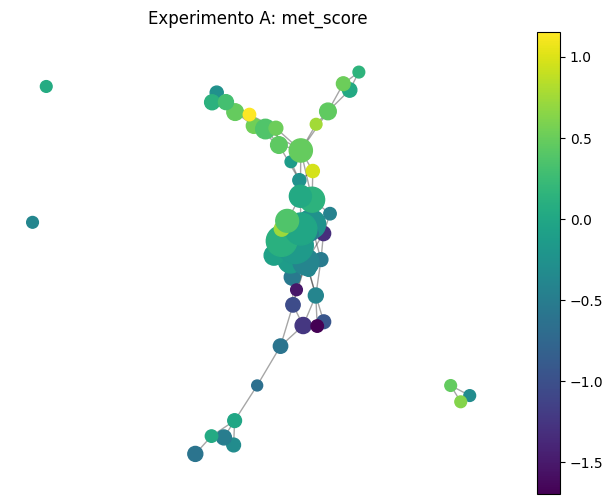

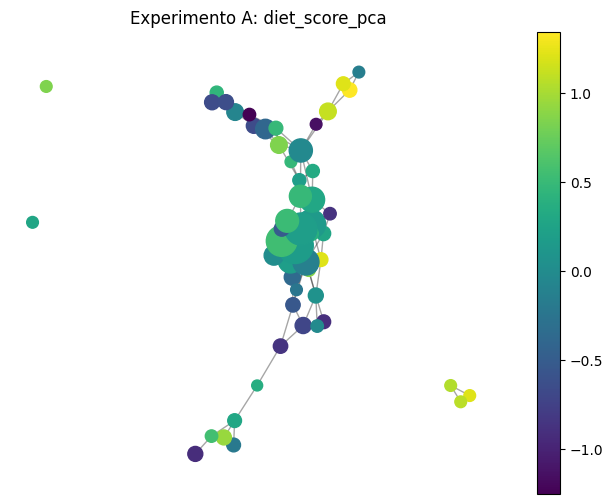

,variable,morans_I,node_range,edge_corr,edge_mad,alignment_score
0,met_score,0.539081,2.294983,0.654368,0.316855,1.237181
2,age,0.489466,1.527513,0.577142,0.233473,0.747665
3,per_total_fat,0.245613,1.326062,0.324615,0.266703,0.325698
1,diet_score_pca,0.210785,1.322781,0.274769,0.276125,0.278823


In [ ]:
# Opción A: Bray--Curtis a nivel de género, pero con lente PCoA1 + PCoA2

lens_alt_A = coords_bray[:, :2]
graph_A, G_A, summary_A = build_mapper_graph(
    X_for_mapper=X_bray5,
    lens_matrix=lens_alt_A,
    n_cubes=10,
    perc_overlap=0.35,
    eps=1.0,
    min_samples=4,
)

print("Resumen del experimento A")
display(summary_A)

draw_mapper_graph_on(graph_A, G_A, meta_clean["met_score"], "Experimento A: met_score")
draw_mapper_graph_on(graph_A, G_A, meta_clean["diet_score_pca"], "Experimento A: diet_score_pca")

rows_A = []
for var in ["met_score", "diet_score_pca", "age", "per_total_fat"]:
    rows_A.append({"variable": var, **mapper_alignment_on_graph(graph_A, G_A, meta_clean[var])})

pd.DataFrame(rows_A).sort_values("alignment_score", ascending=False)

### Opción B. Cambiar la geometría

Prueben una geometría distinta y observen si la estructura sigue contando una historia parecida.

Un experimento razonable es usar **Jaccard** sobre presencia/ausencia a nivel de género.

La pregunta es:

**¿la historia principal se sostiene cuando ya no usamos abundancias relativas, sino solo presencia/ausencia?**

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Resumen del experimento B


,0
nodes,42.000000
edges,69.000000
components,6.000000
covered_samples_fraction,0.547085
giant_component_fraction_of_nodes,0.857143


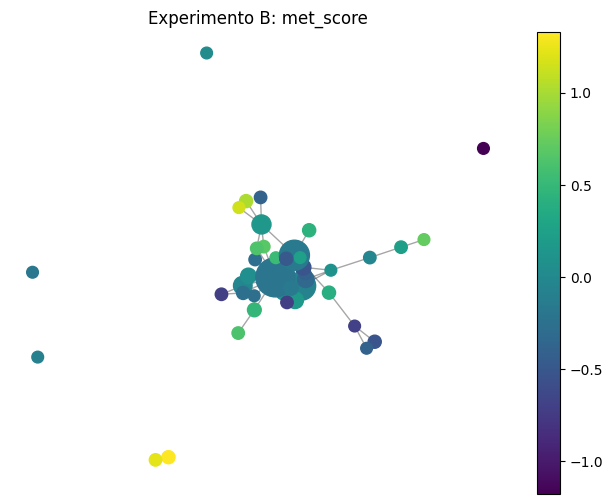

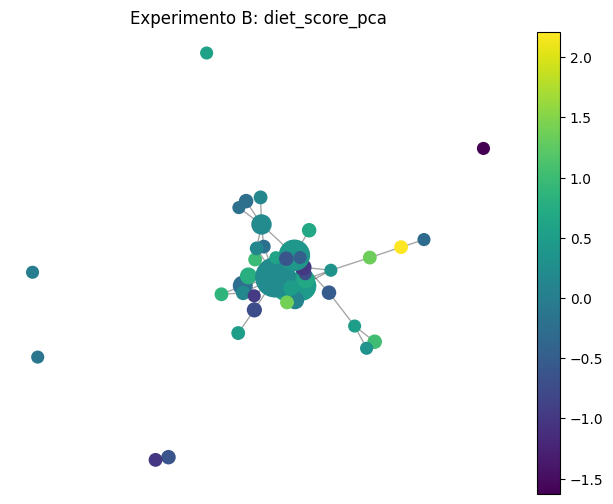

,variable,morans_I,node_range,edge_corr,edge_mad,alignment_score
0,met_score,0.259700,2.020268,0.403198,0.306432,0.524664
2,age,0.147054,2.052219,0.218138,0.410680,0.301787
1,diet_score_pca,0.133180,1.956710,0.199511,0.327570,0.260595
3,per_total_fat,0.121211,1.553379,0.177569,0.295042,0.188287


In [ ]:
# Opción B: Jaccard a nivel de género (presencia/ausencia)

X_bin = (X_rel > 0).astype(int)
D_jacc = pairwise_distances(X_bin.values, metric="jaccard")
coords_jacc, eig_jacc = pcoa(D_jacc, 10)

X_jacc5 = StandardScaler().fit_transform(coords_jacc[:, :5])
density_jacc = knn_density(X_jacc5, 15)
lens_jacc = np.c_[coords_jacc[:, 0], density_jacc]

graph_B, G_B, summary_B = build_mapper_graph(
    X_for_mapper=X_jacc5,
    lens_matrix=lens_jacc,
    n_cubes=10,
    perc_overlap=0.35,
    eps=1.0,
    min_samples=4,
)

print("Resumen del experimento B")
display(summary_B)

draw_mapper_graph_on(graph_B, G_B, meta_clean["met_score"], "Experimento B: met_score")
draw_mapper_graph_on(graph_B, G_B, meta_clean["diet_score_pca"], "Experimento B: diet_score_pca")

rows_B = []
for var in ["met_score", "diet_score_pca", "age", "per_total_fat"]:
    rows_B.append({"variable": var, **mapper_alignment_on_graph(graph_B, G_B, meta_clean[var])})

pd.DataFrame(rows_B).sort_values("alignment_score", ascending=False)

### Pregunta 12

Documenten aquí el camino alterno que exploraron.

Expliquen:

1. **Qué cambiaron** respecto al análisis principal.  
2. **Por qué ese cambio parecía razonable**.  
3. **Qué encontraron**.  
4. **Si ese camino refuerza, debilita o no cambia mucho la historia principal**.  
5. **Si el resultado fue débil o fallido, por qué sigue siendo informativo**.

### Respuesta del equipo
En este camino alterno cambiamos el lente del Mapper. En el análisis principal usamos PCoA1 + densidad local, mientras que aquí usamos PCoA1 + PCoA2. Este cambio nos pareció razonable por PCoA1 y PCoA2 representan los dos primeros ejes geométricos de la proyección PCoA basada en Bray-Curstis, por lo que podían capturar más información de la estructura global que usar solo PCoA1 junto con densidad.

Encontramos que la historia principal se mantiene y, de hecho, se refuerza. La variable met_score siguió siendo la variable con mejor alineación y su alignment_score aumentó de 0.921 a 1.237. También mejoraron morans_I, edge_corr y node_range, lo que sugiere que los valores de met_score cambian de forma más coherente sobre el grafo y que los nodos conectados tienen valores más similares.

Visualmente, este nuevo lente permite ver una estructura algo más separada que en el análisis principal. El centro aparece más compacto, mientras que el extremo inferior y algunas ramas laterales se alejan más del núcleo principal. Esto podría interpretarse como indicios de subregiones dentro de una nube continua, más que como clusters completamente separados. Además, como el cambio de color de met_score se ve más ordenado que el de diet_score_pca, parece que estas regiones se relacionan más con el perfil cardiometabólico que con el perfil dietario.

En conclusión este camino alterno refuerza la historia principal de que el perfil cardiometabólico sigue organizando mejor la estructura del microbioma que el perfil dietario. Además sugiere que PCoA2 aporta información útil y que la señal no dependía solamente del lente original basado en densidad local.

## Parte 12. Conclusión final

Redacten una conclusión de entre 10 y 15 líneas que responda, con claridad y prudencia, estas preguntas:

1. ¿El microbioma en esta cohorte se organiza mejor como grupos separados o como una estructura continua?
2. ¿Qué cambia de manera más clara al recorrer esa estructura?
3. ¿Qué diferencias aparecen entre regiones o extremos?
4. ¿Qué interpretación biológica les parece razonable?
5. ¿Qué conclusión sería exagerada o injustificada?
6. ¿Qué les enseñó el camino alterno que exploraron, incluso si no funcionó bien?

### Conclusión del equipo
A partir del análisis con Mapper, observamos que el microbioma se organiza principalmente como una estructura continua y no como grupos completamente separados. La variable que cambia de forma más clara al recorrer esa estructura es el perfil cardiometabólico, representado por met_score, ya que mostró los mejores valores de alineación, autocorrelación y coherencia entre nodos conectados.

Esta estructura muestra una transición gradual entre perfiles cardiometabólicos más sanos y menos sanos. En los extremos altos aumentan glucose, waist, HOMA_IR, triglycerides y bmi, mientras disminuyen HDL y adiponectin. Además, en esos extremos aparecen géneros como Prevotella, Haemophilus, Enterobacter y Escherichia; en los extremos bajos aparecen más Akkermansia y Oscillospira.

El continuo dietario sí separa variables de alimentación, pero no muestra contrastes clínicos tan consistentes. El camino alterno con PCoA1 + PCoA2 reforzó la historia principal, porque met_score mejoró sus métricas y la transición visual fue más clara.

Por lo tanto, el microbioma parece reflejar diferencias cardiometabólicas dentro de un continuo. Sin embargo, sería exagerado afirmar causalidad o decir que ciertos géneros provocan directamente alteraciones metabólicas; el análisis muestra asociaciones exploratorias que requieren validación adicional.

Esto coincide con Guzmán-Castañeda et al. (2020), quienes reportan que algunos OTUs relacionados con Escherichia coli y Haemophilus parainfluenzae aumentan en individuos con mayor riesgo cardiometabólico, mientras que OTUs relacionados con Akkermansia muciniphila, Oscillospira y Methanobrevibacter aumentan en individuos con bajo riesgo cardiometabólico. Esto respalda nuestra interpretación de que los extremos del continuo muestran diferencias microbiológicas coherentes con perfiles cardiometabólicos más sanos y menos sanos.  

### Visualización de géneros bacterianos sobre el espacio PCoA 3D

Akkermansia → ['Akkermansia']
Oscillospira → ['Oscillospira']
Methanobrevibacter → ['Methanobrevibacter']
Escherichia → ['Escherichia']
Haemophilus → ['Haemophilus']
Prevotella → ['Paraprevotella', 'Prevotella', '[Prevotella]']


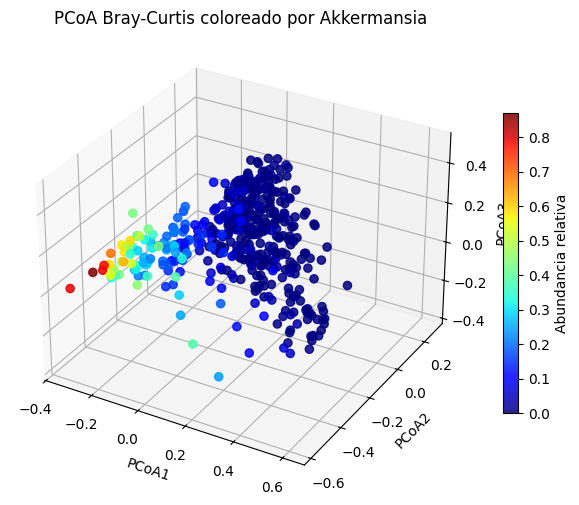

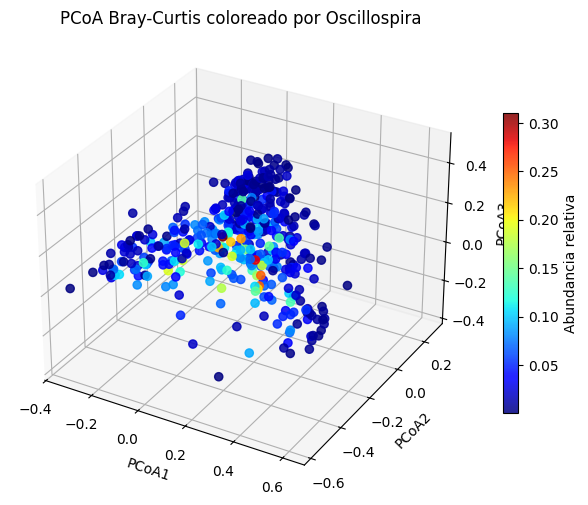

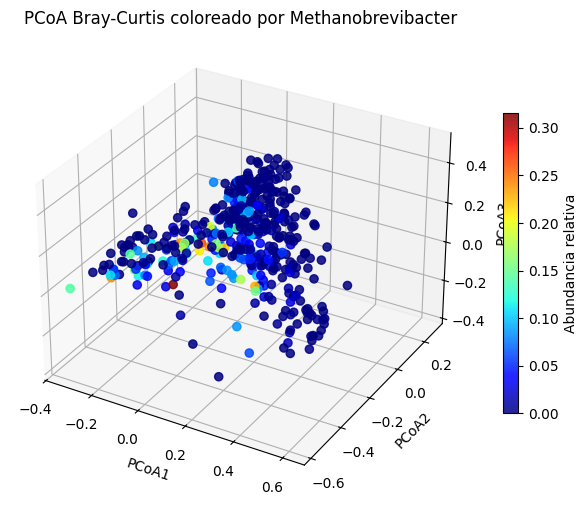

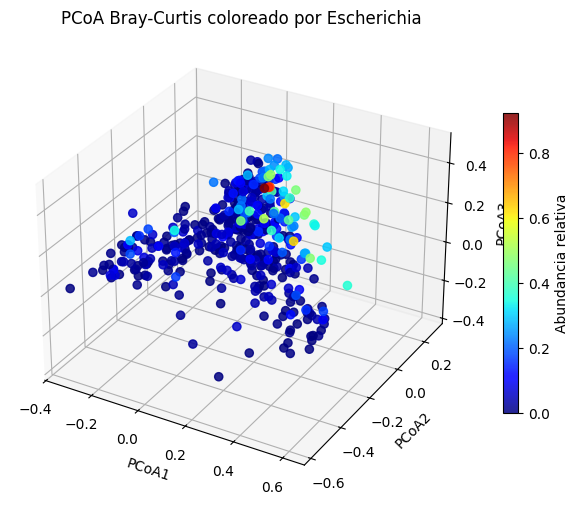

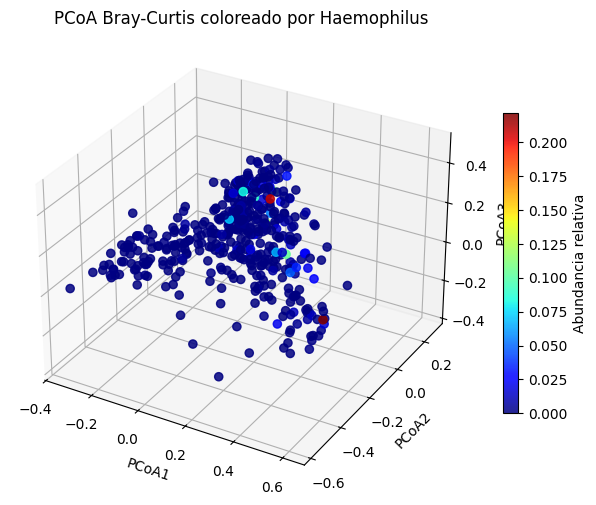

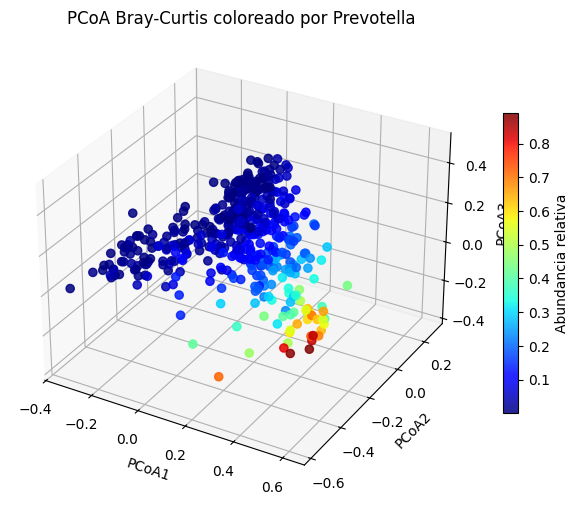

In [ ]:

# 1. Bacterias en la matriz


bacterias = [
    "Akkermansia",
    "Oscillospira",
    "Methanobrevibacter",
    "Escherichia",
    "Haemophilus",
    "Prevotella"
]

def buscar_columnas(X_rel, nombre):
    return [col for col in X_rel.columns if nombre.lower() in str(col).lower()]

for b in bacterias:
    print(b, "→", buscar_columnas(X_rel, b))


# 2. Crear abundancias relativas

abundancias = {}

for b in bacterias:
    cols = buscar_columnas(X_rel, b)
    if len(cols) > 0:
        abundancias[b] = X_rel[cols].sum(axis=1)

    else:
        abundancias[b] = pd.Series(0, index=X_rel.index)
        print(f"Advertencia: no encontré {b} en X_rel")


# 3. Gráfica 3D PCoA1, PCoA2, PCoA3


def plot_bacteria_pcoa3d(coords, values, title):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        coords[:, 2],
        c=values,
        cmap="jet",
        s=35,
        alpha=0.85
    )

    ax.set_xlabel("PCoA1")
    ax.set_ylabel("PCoA2")
    ax.set_zlabel("PCoA3")
    ax.set_title(title)

    cbar = plt.colorbar(sc, ax=ax, shrink=0.65)
    cbar.set_label("Abundancia relativa")
    plt.show()

for b in bacterias:
    plot_bacteria_pcoa3d(
        coords_bray,
        abundancias[b],
        f"PCoA Bray-Curtis coloreado por {b}"
    )

Al visualizar la abundancia relativa de Prevotella sobre las tres primeras coordenadas principales del PCoA basado en Bray-Curtis, se observó que los individuos con mayores abundancias de este género se concentran en una región específica del espacio geométrico, ubicada hacia uno de los extremos del continuo microbiológico. La transición de colores sugiere un gradiente continuo más que la presencia de un clúster aislado, lo que es consistente con la hipótesis de un enterogradiente descrita en estudios previos.

Por otro lado, al analizar Akkermansia, se observó un patrón prácticamente opuesto. Los individuos con mayores abundancias de este género se localizaron predominantemente en el extremo contrario del espacio geométrico. Esta distribución sugiere que Prevotella y Akkermansia caracterizan regiones diferentes del continuo del microbioma y podrían representar configuraciones ecológicas contrastantes dentro de la población estudiada.

La asociación entre ambos géneros se evaluó mediante la correlación de Spearman, debido a que las abundancias relativas de microorganismos suelen presentar distribuciones altamente asimétricas, gran cantidad de ceros y posibles valores extremos. A diferencia de la correlación de Pearson, que asume relaciones lineales y distribuciones aproximadamente normales, la correlación de Spearman se basa en rangos y permite evaluar asociaciones monótonas de manera más robusta. Por esta razón, es una de las métricas más utilizadas en estudios de microbioma y fue también empleada por De la Cuesta-Zuluaga et al. (2018) para identificar grupos de coabundancia bacteriana (CAGs).

Este resultado es particularmente interesante porque coincide de manera cualitativa con lo reportado por De la Cuesta-Zuluaga et al. (2018), quienes encontraron que los grupos microbianos asociados a Prevotella y Akkermansia ocupan regiones distintas de un gradiente continuo de composición microbiana, en lugar de formar enterotipos completamente separados.

### Correlación de Spearman entre Prevotella y Akkermansia

In [ ]:

def buscar_columnas(X_rel, nombre):
    return [col for col in X_rel.columns if nombre.lower() in str(col).lower()]

prevotella_cols = buscar_columnas(X_rel, "Prevotella")
akkermansia_cols = buscar_columnas(X_rel, "Akkermansia")

print("Columnas Prevotella:", prevotella_cols)
print("Columnas Akkermansia:", akkermansia_cols)

prevotella_abund = X_rel[prevotella_cols].sum(axis=1)
akkermansia_abund = X_rel[akkermansia_cols].sum(axis=1)

rho, p = spearmanr(prevotella_abund, akkermansia_abund)

print("Spearman rho =", rho)
print("p-value =", p)

Columnas Prevotella: ['Paraprevotella', 'Prevotella', '[Prevotella]']
Columnas Akkermansia: ['Akkermansia']
Spearman rho = -0.323077568648868
p-value = 2.705724531115941e-12


Se evaluó la asociación entre las abundancias realtivas de Prevotella y Akkermansia mediante la correlación de Spearman. Se observó una correlación negativa moderada ($ρ=-0.323$,$p < 0.001$). Indicando que los individuos con mayores abundancias de Prevotella tienden a presentar menores abundancias de Akkermansia. Este resultado es consistente con la distribución observada en el PCoA, donde ambos géneros aparecen enriquecidos en regiones opuestas del continuo microbiológico. La relación observada sugiere que Prevotella y Akkermansia caracterizan configuraciones ecológicas contrastantes dentro de la estructura global del microbioma.


### Cálculo de abundancias relativas de géneros clave

In [ ]:
oscillospira_abund = X_rel[buscar_columnas(X_rel, "Oscillospira")].sum(axis=1)

methanobrevibacter_abund = X_rel[
    buscar_columnas(X_rel, "Methanobrevibacter")
].sum(axis=1)

escherichia_abund = X_rel[
    buscar_columnas(X_rel, "Escherichia")
].sum(axis=1)

haemophilus_abund = X_rel[
    buscar_columnas(X_rel, "Haemophilus")
].sum(axis=1)

### Matriz de correlaciones de Spearman entre géneros clave

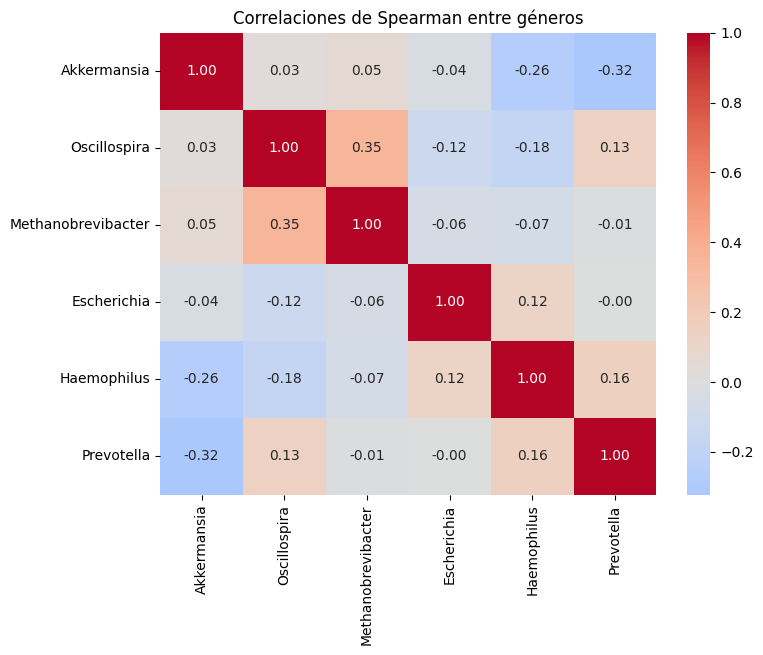

In [ ]:
bacs = pd.DataFrame({

    "Akkermansia": akkermansia_abund,
    "Oscillospira": oscillospira_abund,
    "Methanobrevibacter": methanobrevibacter_abund,
    "Escherichia": escherichia_abund,
    "Haemophilus": haemophilus_abund,
    "Prevotella": prevotella_abund

})

corr = bacs.corr(method="spearman")
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlaciones de Spearman entre géneros")
plt.show()

Como análisis complementario, se exploraron correlaciones entre los géneros bacterianos identificados previamente en los extremos del Mapper.  Se observó una correlación negativa moderada entre Akkermansia y Prevotella ($\rho=-0.32$, $p < 0.001$), así como entre Akkermansia y Haemophilus ($\rho=-0.26$). Este resultado es consistente con la estructura observada en el Mapper, donde Akkermansia se encontraba asociada al extremo con mejor perfil cardiometabólico, mientras que Prevotella y Haemophilus se asociaban al extremo con mayor alteración metabólica. Además, las visualizaciones sobre el espacio geométrico del PCoA mostraron que Akkermansia y Prevotella se enriquecen en regiones opuestas del continuo microbiológico.

Por otra parte, Oscillospira y Methanobrevibacter, dos de los géneros asociados al extremo cardiometabólicamente más saludable en nuestro análisis, presentaron la correlación positiva más alta observada entre los géneros estudiados ($\rho=0.35$). Este hallazgo sugiere que ambos microorganismos tienden a coexistir en individuos con configuraciones similares del microbioma y proporciona evidencia adicional de que las bacterias identificadas en el extremo saludable no fueron seleccionadas de manera aislada, sino que reflejan patrones ecológicos consistentes dentro de la estructura global del microbioma.

### Mapper coloreado por géneros asociados al continuo cardiometabólico

Akkermansia → ['Akkermansia']


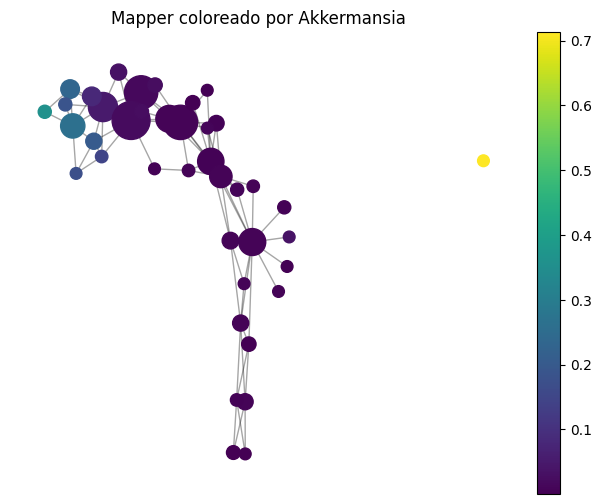

Prevotella → ['Paraprevotella', 'Prevotella', '[Prevotella]']


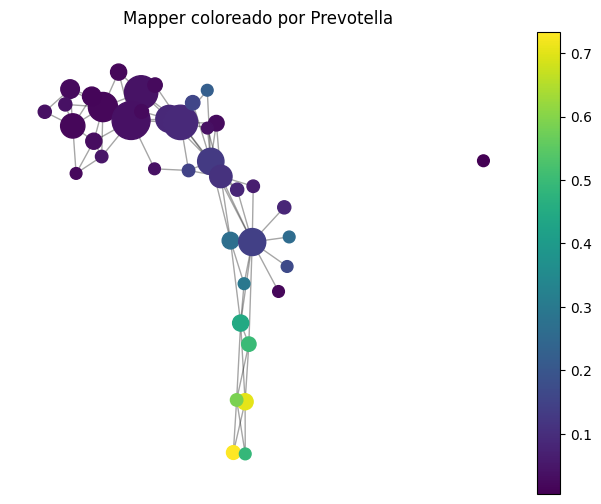

Oscillospira → ['Oscillospira']


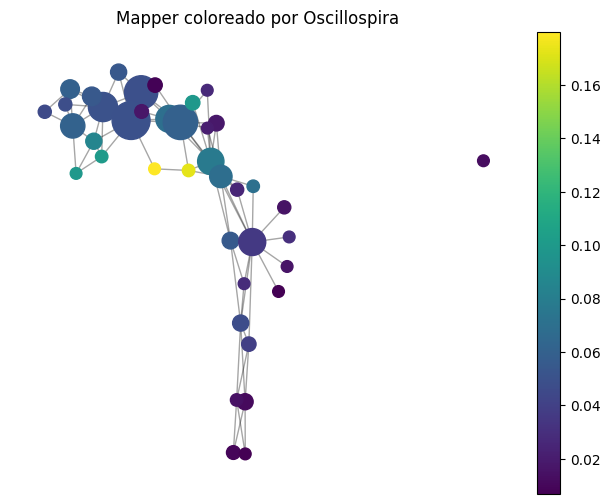

Methanobrevibacter → ['Methanobrevibacter']


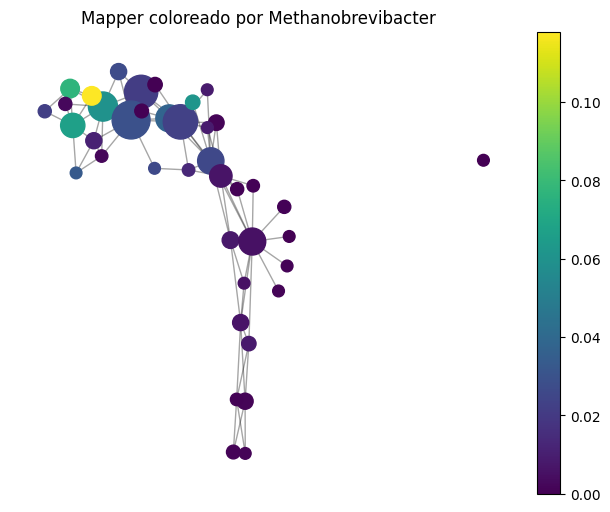

Escherichia → ['Escherichia']


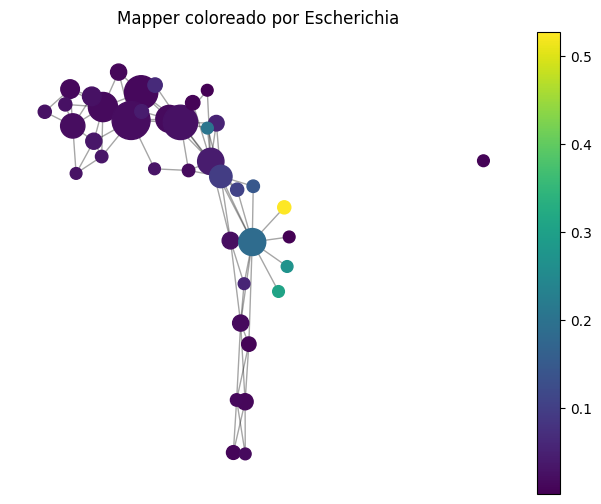

Haemophilus → ['Haemophilus']


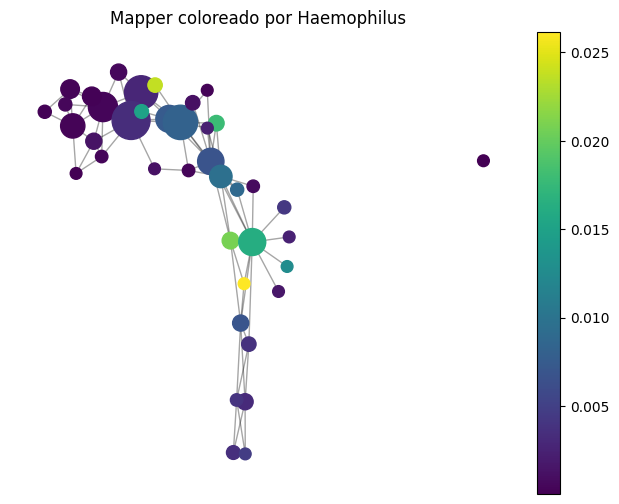

In [ ]:
def genus_abundance(X_rel, genus):
    cols = buscar_columnas(X_rel, genus)
    print(genus, "→", cols)
    if len(cols) == 0:
        return pd.Series(0, index=X_rel.index)
    return X_rel[cols].sum(axis=1)

for genus in [
    "Akkermansia",
    "Prevotella",
    "Oscillospira",
    "Methanobrevibacter",
    "Escherichia",
    "Haemophilus"
]:
    abund = genus_abundance(X_rel, genus)

    # importante: alinear con meta_clean.index
    abund = abund.loc[meta_clean.index]

    draw_mapper_graph(
        graph,
        G,
        abund,
        f"Mapper coloreado por {genus}"
    )

Aunque el analisis diferencial entre extremos ya identificaba los géneros asociados a cada región del continuo, colorear el Mapper permitió verificar si esas diferencias eran coherentes con la estructura geométrica del grafo. Para ello, cada nodo fue coloreado según la abundancia promedio del género en los individuos que lo componen. Se observó que Akkermansia, Oscillospira y Methanobrevibacter presentaron mayor abundancia en nodos asociados con valores bajos de met_score y perfiles cardiometabólicos más saludables, mientras que Prevotella, Escherichia y Haemophilus se enriquecieron en nodos con valores altos de met_score y perfiles más alterados.

Estos resultados son consistentes con el análisis diferenciaal previo y sugieren que ciertos géneros bacterianos caracterizan distintas regiones del continuo cardiometabólico identificado por Mapper. Por tanto, la estructura observada no se interpreta como enterotipos separados, sino como un gradiente microbiológico asociado al perfil cardiometabólico.

Es importante aclarar que estos resultados no se interpretan como enterotipos, ya que no estamos proponiendo grupos discretos o completamente separados de microbioma. Al contrario, la evidencia obtenida por PCoA, homología persistente y Mapper sugiere una estructura continua. Por eso, las bacterias identificadas se interpretan como géneros que se enriquecen gradualmente en distintas regiones del continuo microbiológico, no como marcadores de enterotipos cerrados.

### Construcción de un índice microbiológico asociado a met_score

In [ ]:
def genus_abundance(genus):
    cols = buscar_columnas(X_rel, genus)
    return X_rel[cols].sum(axis=1).loc[meta_clean.index]

# Extremo bajo (más saludable)
healthy_genera = [
    "Akkermansia",
    "Methanobrevibacter",
    "Oscillospira",
    "Christensenella",
    "Propionispora"
]

# Extremo alto (más alterado)

altered_genera = [

    "Haemophilus",
    "Prevotella",
    "Enterobacter",
    "Escherichia"

]

healthy_index = sum(genus_abundance(g) for g in healthy_genera)
altered_index = sum(genus_abundance(g) for g in altered_genera)

microbial_gradient = altered_index - healthy_index
rho, p = spearmanr(microbial_gradient, meta_clean["met_score"])

print("Spearman rho =", rho)
print("p-value =", p)

gradient_df = pd.DataFrame({
    "healthy_index": healthy_index,
    "altered_index": altered_index,
    "microbial_gradient": microbial_gradient,
    "met_score": meta_clean["met_score"]
})

display(gradient_df.head())

Spearman rho = 0.25743440676882856
p-value = 3.494897519622426e-08


,healthy_index,altered_index,microbial_gradient,met_score
ID,,,,
MI_001_H,0.197791,0.081969,-0.115821,0.917642
MI_002_H,0.412818,0.084367,-0.328451,0.395638
MI_003_H,0.000100,0.061099,0.060999,0.027026
MI_004_H,0.025555,0.285500,0.259944,-1.869057
MI_005_H,0.015181,0.007326,-0.007855,-4.543375


Como analisis c0omplementario, construimos un índice bacteriano utilizando los géneros que mostraron las mayores diferencias entre los extremos del continuo cardiometabólico identificado previamente mediante Mapper. Para ello, agrupamos los géneros enriquecidos en el extremo más saludable en un Healthy Index y los géneros enriquecidos en el extremo más alterado en un Altered Index. Posteriormente definimos un Microbial Gradient como la diferencia entre ambos índices (Altered Index − Healthy Index), con el objetivo de resumir en una sola variable el balance entre bacterias asociadas a perfiles cardiometabólicos saludables y alterados.

Una vez construido este gradiente bacteriano evaluamos su asociación con met_score mediante la correlación de Spearman. Obtuvimos una correlación positiva débil pero estadísticamente significativa ($\rho = 0.257, p < 0.001$). Aunque la magnitud de la asociación es modesta, el resultado sugiere que los géneros identificados en los extremos del Mapper contienen información relacionada con el gradiente cardiometabólico observado en la población. En otras palabras, los individuos con una mayor proporción relativa de bacterias asociadas al extremo alterado tendieron a presentar valores más altos de met_score, mientras que aquellos con mayor presencia de bacterias asociadas al extremo saludable tendieron a ubicarse hacia valores más bajos.

Consideraamos este resultado como una validación adicional de los hallazgos obtenidos previamente mediante PCoA, Mapper y análisis diferencial. Si bien el índice no explica por sí solo toda la variabilidad cardiometabólica, proporciona evidencia de que las bacterias identificadas en los extremos del continuo contribuyen de manera coherente a la estructura cardiometabólica observada en el microbioma.

### Visualización del índice bacteriano y met_score

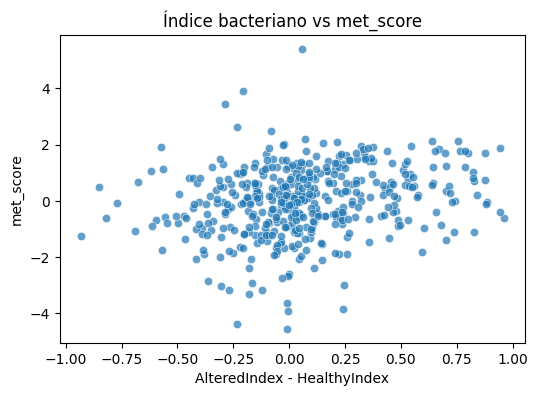

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=gradient_df,
    x="microbial_gradient",
    y="met_score",
    alpha=0.7
)
plt.title("Índice bacteriano vs met_score")
plt.xlabel("AlteredIndex - HealthyIndex")
plt.ylabel("met_score")
plt.show()

En la nube de puntos no se observa una relación fuerte o perfectamente lineal, ya que existe bastante dispersión entre los individuos. Sin embargo, sí aparece una tendencia positiva general: conforme aumenta el índice bacteriano propuesto, también tienden a aumentar los valores de met_score. Esto coincide con la correlación débil pero significativa encontrada, y sugiere que los géneros incluidos en el índice capturan una parte pequeña, pero coherente, del gradiente cardiometabólico.

### Conclusión

El análisis realizado sugiere que el microbioma intestinal de esta población se organiza principalmente como un continuo microbiológico, más que como grupos o enterotipos completamente separados. Entre las variables estudiadas, met_score fue la que mostró la asociación más clara con la estructura identificada mediante Mapper, indicaando una transición gradual entre perfiles cardiometabólicos más saludables y más alterados.

Los análisis diferenciales permitieron identificar géneros bacterianos asociados a cada extremo del continuo. Geeneros como Akkermansia, Oscillospira y Methanobrevibacter se asociaron principalmente con el extremo más saludable, mientras que Prevotella, Escherichia, Haemophilus y Enterobacter se asociaron con el extremo más alterado. Estas asociaciones fueron consistentes con las visualizaciones en PCoA, las correlaciones de Spearman y el coloreado de los nodos del Mapper.

Como validación adicional, se construyó un Microbial Gradient a partir de los géneros enriquecidos en ambos extremos del continuo. Aunque la asociación observada con met_score fue débil-moderada ($\rho = 0.257$), el resultado fue estadísticamente significativo y coherente con la estructura identificada previamente. Esto sugiere que los generos seleccionaados capturan parcialmente el gradiente cardiometabólico observado en el microbioma.

En conjunto los resultados apoyan la hipótesis de que la composición del microbioma y el perfil cardiometabólico cambian de manera coordinada a lo largo de un gradiente continuo. Sin embargo, este estudio es de naturaleza exploratoria y no permite establecer relaciones causales. Futuras investigaciones podrían validar estos hallazgos en otras cohortes y profundizar en los mecanismos biológicos que conectan la estructura del microbioma con el estado cardiometabólico.

### Referencias

Guzmán-Castañeda, S. J., Ortega-Vega, E. L., de la Cuesta-Zuluaga, J., Velásquez-Mejía, E. P., Rojas, W., Bedoya, G., & Escobar, J. S. (2020). Gut microbiota composition explains more variance in the host cardiometabolic risk than genetic ancestry. Gut Microbes, 11(2), 191–204. https://doi.org/10.1080/19490976.2019.1634416